# MAGPIE — May 2026 Demo

Run cells top to bottom. **Cell 1** starts all nodes. **Cell 2** makes rclpy importable in VS Code.

Set `OBJECT` in Cell 3 to the thing on the table, e.g. `'red block'`.

In [1]:
import subprocess, os, time

SAM3_PY  = os.path.expanduser('~/sam3_env/bin/python3')
SAM3_SCR = os.path.expanduser('~/magpie_control/scripts/sam3_infer.py')
ROS      = 'source /opt/ros/humble/setup.bash && source ~/ws_ctrl/install/setup.bash'

def ros_proc(cmd, log):
    open(log, 'w').close()
    return subprocess.Popen(f'{ROS} && {cmd}', shell=True, executable='/bin/bash',
                            stdout=open(log, 'a'), stderr=subprocess.STDOUT)

print('Killing stale processes...')
for p in ['ur5_node', 'gripper_node', 'realsense2_camera', 'sam3_infer', 'slip_guard_node']:
    subprocess.run(f'pkill -9 -f {p}', shell=True)
subprocess.run('rm -f /tmp/sam3.sock', shell=True)
time.sleep(3)

PROCS = {}
PROCS['ur5']     = ros_proc('ros2 run magpie_control ur5_node',     '/tmp/log_ur5.txt')
PROCS['gripper'] = ros_proc('ros2 run magpie_control gripper_node', '/tmp/log_gripper.txt')
PROCS['camera']  = ros_proc(
    'ros2 run realsense2_camera realsense2_camera_node --ros-args -r __ns:=/camera/gripper_camera',
    '/tmp/log_camera.txt')
PROCS['slip_guard'] = ros_proc(
    f'python3 {os.path.expanduser("~/magpie_control/scripts/slip_guard_node.py")}',
    '/tmp/log_slip_guard.txt')
PROCS['sam3']    = subprocess.Popen(
    [SAM3_PY, SAM3_SCR, '--socket'],
    stdout=open('/tmp/log_sam3.txt', 'w'), stderr=subprocess.STDOUT)

# ── Grasp memory (force priors + DINO RAG) ──────────────────────────
import sys as _sys
_sys.path.insert(0, os.path.expanduser('~/magpie_control/scripts'))
from grasp_memory import GraspMemory
gm = GraspMemory(os.path.expanduser('~/magpie_control/data/grasp_log'))
print(f'GraspMemory loaded — {len(gm._priors)} known objects')

print('Waiting for SAM3 (up to 90s)...')
for i in range(90):
    time.sleep(1)
    if os.path.exists('/tmp/sam3.sock'):
        print(f'  SAM3 ready after {i+1}s')
        break
    if PROCS['sam3'].poll() is not None:
        print('  SAM3 crashed:'); print(open('/tmp/log_sam3.txt').read()[-600:])
        break
    if (i+1) % 20 == 0:
        print(f'  {i+1}s...')

time.sleep(3)
print()
for n, p in PROCS.items():
    status = 'OK' if p.poll() is None else f'EXITED  -> tail /tmp/log_{n}.txt'
    print(f'  {n:<10} {status}')

Killing stale processes...
Waiting for SAM3 (up to 90s)...
  SAM3 ready after 14s

  ur5        OK
  gripper    OK
  camera     OK
  sam3       OK


In [ ]:
# ── Memory Manager ────────────────────────────────────────────────────────────
# Run this to inspect, rename, or delete entries from grasp memory.
#
# Override auto-detection for next pickup:
#   ACTIVE_OVERRIDE = 'measuring tape'
# Clear it after:
#   ACTIVE_OVERRIDE = ''

ACTIVE_OVERRIDE = ''   # ← set this before running 17ea9af9 if detection is wrong

print('=== Grasp Memory Contents ===')
if 'gm' not in dir():
    import sys; sys.path.insert(0, os.path.expanduser('~/magpie_control/scripts'))
    from grasp_memory import GraspMemory
    gm = GraspMemory(os.path.expanduser('~/magpie_control/data/grasp_log'))
for _name, _p in sorted(gm._priors.items(), key=lambda x: -x[1]['n']):
    print(f'  {_name:<30} n={_p["n"]:>3}  force={_p["x"]:.1f}N  std={_p["P"]**0.5:.2f}N')
print(f'\nTotal: {len(gm._priors)} objects')

# ── To delete a wrong entry ────────────────────────────────────────────────
# del gm._priors['wrong name']; gm._save_priors(); print('Deleted.')

# ── To rename a wrong entry ───────────────────────────────────────────────
# gm._priors['correct name'] = gm._priors.pop('wrong name')
# gm._save_priors(); print('Renamed.')

# ── To reset a single object to re-learn from scratch ─────────────────────
# del gm._priors['measuring tape']; gm._save_priors(); print('Reset.')


In [2]:
# Load ROS shared libraries so rclpy imports in any VS Code kernel
import sys, os, ctypes, glob

for _d in [
    '/opt/ros/humble/lib/x86_64-linux-gnu',
    '/opt/ros/humble/lib',
    '/home/user/ws_ctrl/install/magpie_msgs/lib',
    '/home/user/ws_ctrl/install/magpie_control/lib',
]:
    for _so in sorted(glob.glob(_d + '/*.so*')):
        try:
            ctypes.CDLL(_so, mode=ctypes.RTLD_GLOBAL)
        except Exception:
            pass

for _p in [
    '/opt/ros/humble/local/lib/python3.10/dist-packages',
    '/opt/ros/humble/lib/python3.10/site-packages',
    '/home/user/ws_ctrl/install/magpie_msgs/local/lib/python3.10/dist-packages',
    '/home/user/ws_ctrl/install/magpie_control/lib/python3.10/site-packages',
    '/home/user/.local/lib/python3.10/site-packages',
    '/home/user/magpie_control/src',
    '/home/user/magpie_control/scripts',
]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

import rclpy
print('rclpy OK')

         at line 253 in /opt/ros/humble/include/class_loader/class_loader/class_loader_core.hpp
         at line 253 in /opt/ros/humble/include/class_loader/class_loader/class_loader_core.hpp


rclpy OK


In [3]:
import time, re, json, tempfile, base64, socket as _sock
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D
import cv2
%matplotlib inline
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['figure.dpi']     = 80   # keeps output file size small for GitHub

from rclpy.node import Node
from rclpy.qos import QoSProfile, ReliabilityPolicy, DurabilityPolicy
from sensor_msgs.msg import Image as RosImage, CameraInfo
from geometry_msgs.msg import PoseStamped, Pose
from std_srvs.srv import Trigger
from cv_bridge import CvBridge
from magpie_msgs.msg import GripperState
from magpie_msgs.srv import MoveLinear, SetGripperForce, SetGripperPosition
from magpie_control import poses
from magpie_control.homog_utils import homog_xform, R_krot
from magpie_control.gripper_arc import fingertip_drop
from google import genai
from google.genai import types as gtypes
from pointcloud_utils import build_segmented_pcd, denoise_pcd, analyse_pcd

# --- CONFIG ---
OBJECT         = ''   # blank = Gemini auto-detects
SAM3_SOCK      = '/tmp/sam3.sock'
GEMINI_KEY     = os.environ.get('GEMINI_API_KEY', '')
GRIPPER_LEN    = 0.231
HARD_FLOOR_Z   = 0.025
TABLE_Z        = None   # set by running the measure cell below
APPROACH_H     = 0.10
_TCP_TO_CAM    = homog_xform(R_krot([0, 0, 1], np.pi/2), [0, 0, 0.120])

if not GEMINI_KEY:
    print('WARNING: GEMINI_API_KEY not set.')
print('Imports OK')

Imports OK


In [4]:
# Helper: quaternion <-> rotation vector
def _quat_to_rv(w, x, y, z):
    a = 2.0 * np.arccos(np.clip(w, -1, 1))
    s = np.sin(a / 2)
    return np.zeros(3) if s < 1e-10 else a * np.array([x, y, z]) / s

def _rv_to_quat(rv):
    a = np.linalg.norm(rv)
    if a < 1e-10:
        return (1., 0., 0., 0.)
    ax = rv / a
    return (np.cos(a/2), ax[0]*np.sin(a/2), ax[1]*np.sin(a/2), ax[2]*np.sin(a/2))

def _mat_to_pose(mat):
    v = poses.pose_mtrx_to_vec(np.array(mat))
    w, x, y, z = _rv_to_quat(np.array(v[3:]))
    p = Pose()
    p.position.x, p.position.y, p.position.z = v[0], v[1], v[2]
    p.orientation.w, p.orientation.x = w, x
    p.orientation.y, p.orientation.z = y, z
    return p

# QoS profiles matching RealSense D405 publisher settings
img_qos = QoSProfile(depth=1, reliability=ReliabilityPolicy.RELIABLE,
                     durability=DurabilityPolicy.TRANSIENT_LOCAL)
inf_qos = QoSProfile(depth=1, reliability=ReliabilityPolicy.RELIABLE,
                     durability=DurabilityPolicy.VOLATILE)

class Demo(Node):
    def __init__(self):
        super().__init__('magpie_demo')
        self.bridge = CvBridge()
        self.color = self.depth = self.caminfo = self.tcp = self.gs = None
        NS = '/camera/gripper_camera/camera'
        self.create_subscription(
            RosImage,    NS+'/color/image_raw',
            lambda m: setattr(self, 'color', self.bridge.imgmsg_to_cv2(m, 'rgb8')), img_qos)
        self.create_subscription(
            RosImage,    NS+'/depth/image_rect_raw',
            lambda m: setattr(self, 'depth', self.bridge.imgmsg_to_cv2(m, 'passthrough')), img_qos)
        self.create_subscription(
            CameraInfo,  NS+'/color/camera_info',
            lambda m: setattr(self, 'caminfo', m), inf_qos)
        self.create_subscription(
            GripperState, '/gripper/state',
            lambda m: setattr(self, 'gs', m), 1)
        self.create_subscription(
            PoseStamped, '/arm/tcp_pose',
            self._tcp_cb, 1)
        self.mv  = self.create_client(MoveLinear,         '/arm/move_l')
        self.tch = self.create_client(Trigger,             '/arm/teach_mode')
        self.opn = self.create_client(Trigger,             '/gripper/open')
        self.cls = self.create_client(Trigger,             '/gripper/close')
        self.frc = self.create_client(SetGripperForce,     '/gripper/set_force')
        self.pos = self.create_client(SetGripperPosition,  '/gripper/set_position')
        self.clr = self.create_client(Trigger,             '/gripper/clear_error')

    def _tcp_cb(self, m):
        p = m.pose
        rv = _quat_to_rv(p.orientation.w, p.orientation.x, p.orientation.y, p.orientation.z)
        self.tcp = poses.pose_vec_to_mtrx([p.position.x, p.position.y, p.position.z, *rv])

    def spin(self, n=10, t=0.15):
        for _ in range(n):
            rclpy.spin_once(self, timeout_sec=t)

    def _call(self, client, req, timeout=30.):
        client.wait_for_service(timeout_sec=4.)
        fut = client.call_async(req)
        rclpy.spin_until_future_complete(self, fut, timeout_sec=timeout)
        return fut.result()

    def move(self, mat, spd=0.08, acc=0.2):
        r = MoveLinear.Request()
        r.target_pose = _mat_to_pose(mat)
        r.speed = spd; r.acceleration = acc; r.async_mode = False
        resp = self._call(self.mv, r)
        if not resp.success:
            raise RuntimeError(resp.message)

    def open_g(self):  return self._call(self.opn, Trigger.Request())
    def close_g(self): return self._call(self.cls, Trigger.Request())

    def set_force(self, n):
        r = SetGripperForce.Request(); r.max_force = float(n)
        return self._call(self.frc, r)

    def set_pos(self, mm):
        r = SetGripperPosition.Request(); r.position = float(max(0, mm))
        return self._call(self.pos, r)

    def clear_err(self):
        # Re-enable AX-12 torque after overload shutdown (reset_packet_overload).
        # NOTE: this resets force limit to 2N, so call set_force() again after.
        if not self.clr.wait_for_service(timeout_sec=1.):
            return None
        return self._call(self.clr, Trigger.Request())

    def slip_guard_enable(self, force_n, slip_thresh, obj_u=None, obj_v=None, force_step=1.0):
        """Send config (force, thresh, object pixel coords, reclamp step) then enable the SlipGuardNode."""
        if not hasattr(self, '_sg_en'):
            from std_msgs.msg import Float32MultiArray
            self._sg_cfg_pub = self.create_publisher(
                Float32MultiArray, 'slip_guard/config', 1)
            self._sg_en  = self.create_client(Trigger, 'slip_guard/enable')
            self._sg_dis = self.create_client(Trigger, 'slip_guard/disable')
            from std_msgs.msg import String as _SgStr
            self._sg_events = []
            self.create_subscription(_SgStr, '/slip_guard/events',
                lambda msg: self._sg_events.append(msg.data), 10)
        from std_msgs.msg import Float32MultiArray
        cfg = Float32MultiArray()
        # [force, thresh, obj_u, obj_v] — pixel coords tell guard where to sample depth
        cfg.data = [float(force_n), float(slip_thresh),
                    float(obj_u) if obj_u is not None else -1.,
                    float(obj_v) if obj_v is not None else -1.,
                    float(force_step)]
        self._sg_events = []  # reset for this grasp — fresh DAgger log
        self._sg_cfg_pub.publish(cfg)
        time.sleep(0.1)
        if not self._sg_en.wait_for_service(timeout_sec=1.):
            print('[slip_guard] node not running — guard skipped')
            return
        self._call(self._sg_en, Trigger.Request())

    def slip_guard_disable(self):
        if hasattr(self, '_sg_dis') and self._sg_dis.wait_for_service(timeout_sec=0.5):
            self._call(self._sg_dis, Trigger.Request())

    def unteach(self):
        if not self.tch.wait_for_service(timeout_sec=2.):
            return
        r = self._call(self.tch, Trigger.Request())
        if r and 'enabled' in r.message.lower():
            self._call(self.tch, Trigger.Request())

    def wait_sensors(self, timeout=20.):
        t0 = time.time()
        while time.time() - t0 < timeout:
            rclpy.spin_once(self, timeout_sec=0.15)
            if all(v is not None for v in [self.color, self.depth, self.caminfo, self.tcp]):
                return True
        return False

try:
    rclpy.init()
except RuntimeError:
    pass

try:
    node.destroy_node()
except Exception:
    pass

node = Demo()
ok   = node.wait_sensors(20.)
print('Sensors ready:', ok,
      '| color:', node.color is not None,
      '| depth:', node.depth is not None,
      '| tcp:',   node.tcp   is not None)

Sensors ready: True | color: True | depth: True | tcp: True


In [5]:
# ── Measure TABLE_Z + capture background point cloud ─────────────────────────
# Run ONCE on a clear table (no object in view).
# Stores TABLE_Z and BG_PTS (background cloud) used for object isolation.
node.spin(5)
d   = node.depth.copy()
ci  = node.caminfo
tcp = node.tcp.copy()
fx, fy = ci.k[0], ci.k[4]
cx, cy = ci.k[2], ci.k[5]
T      = tcp @ _TCP_TO_CAM

# ── TABLE_Z from central ROI ──────────────────────────────────────────────────
h, w   = d.shape
roi    = d[h//2-40:h//2+40, w//2-40:w//2+40].astype(float)
valid  = roi[roi > 0]
if len(valid) < 20:
    print('Not enough depth readings — point camera at the table')
else:
    dm_tbl  = float(np.median(valid)) / 1000.
    p_tbl   = np.array([0., 0., dm_tbl])
    TABLE_Z = float((T @ np.array([*p_tbl, 1.]))[2])
    print(f'TABLE_Z = {TABLE_Z*1000:.1f} mm')

# ── Background point cloud — full frame, every valid depth pixel ──────────────
# Stored as BG_PTS for background-subtraction in the pickup cell.
# When the object is placed, foreground pts far from any BG_PT are the object.
ys_bg, xs_bg = np.where(d > 0)
zs_bg = d[ys_bg, xs_bg].astype(np.float64) / 1000.
x_bg  = (xs_bg - cx) * zs_bg / fx
y_bg  = (ys_bg - cy) * zs_bg / fy
pts_bg_cam = np.stack([x_bg, y_bg, zs_bg, np.ones_like(zs_bg)], axis=1)
BG_PTS = (T @ pts_bg_cam.T).T[:, :3]   # world-frame background cloud
print(f'Background cloud: {len(BG_PTS)} pts  '
      f'Z range {BG_PTS[:,2].min()*1000:.0f}–{BG_PTS[:,2].max()*1000:.0f} mm')
print('TABLE_Z and BG_PTS captured. Place the object and run the full pickup cell.')


TABLE_Z = 34.6 mm  — copy this into the OBJECT config above
(Set TABLE_Z = 0.0346 in cell 3 config)


---
## 1. Move Arm

HOME  x=-0.2003  y=-0.6044  z=0.3964
UP    x=-0.2003  y=-0.6044  z=0.3964  dZ=0.0mm
Home.


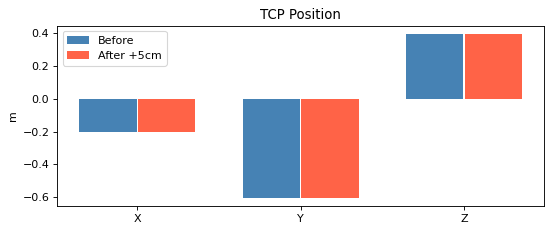

In [5]:
node.spin(5)
home = node.tcp.copy()
v0   = poses.pose_mtrx_to_vec(home)
print(f'HOME  x={v0[0]:.4f}  y={v0[1]:.4f}  z={v0[2]:.4f}')

# Move 5 cm up then return
tgt = home.copy(); tgt[2, 3] += 0.05
node.move(tgt, spd=0.05)
time.sleep(0.4); node.spin(5)
v1 = poses.pose_mtrx_to_vec(node.tcp)
print(f'UP    x={v1[0]:.4f}  y={v1[1]:.4f}  z={v1[2]:.4f}  dZ={(v1[2]-v0[2])*1000:.1f}mm')
node.move(home, spd=0.05)
print('Home.')

fig, ax = plt.subplots(figsize=(7, 3))
x = np.arange(3)
ax.bar(x - .18, v0[:3], .35, label='Before',  color='steelblue')
ax.bar(x + .18, v1[:3], .35, label='After +5cm', color='tomato')
ax.set_xticks(x); ax.set_xticklabels(['X', 'Y', 'Z'])
ax.set_ylabel('m'); ax.set_title('TCP Position'); ax.legend()
plt.tight_layout(); plt.show()

---
## 2. Gripper Control

Open     pos=103.6mm  force=0.000N  temp=34.5C
50mm     pos=49.7mm  force=0.000N  temp=34.5C
Closed   pos=-4.4mm  force=2.226N  temp=35.0C


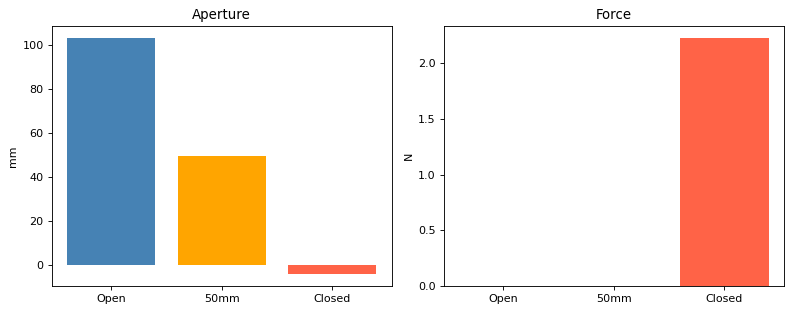

In [6]:
node.open_g();             time.sleep(0.6); node.spin(8); s0 = node.gs
node.set_force(5.)
node.set_pos(50.);         time.sleep(1.2); node.spin(8); s1 = node.gs
node.set_force(8.)
node.close_g();            time.sleep(2.5); node.spin(8); s2 = node.gs
node.open_g()

for lbl, s in [('Open', s0), ('50mm', s1), ('Closed', s2)]:
    if s:
        print(f'{lbl:<8} pos={s.position:.1f}mm  force={s.force:.3f}N  temp={s.temperature:.1f}C')

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 4))
states = ['Open', '50mm', 'Closed']
cols   = ['steelblue', 'orange', 'tomato']
a1.bar(states, [s.position if s else 0 for s in [s0, s1, s2]], color=cols)
a1.set_ylabel('mm'); a1.set_title('Aperture')
a2.bar(states, [s.force if s else 0 for s in [s0, s1, s2]], color=cols)
a2.set_ylabel('N');  a2.set_title('Force')
plt.tight_layout(); plt.show()

---
## 3. Poll Cameras

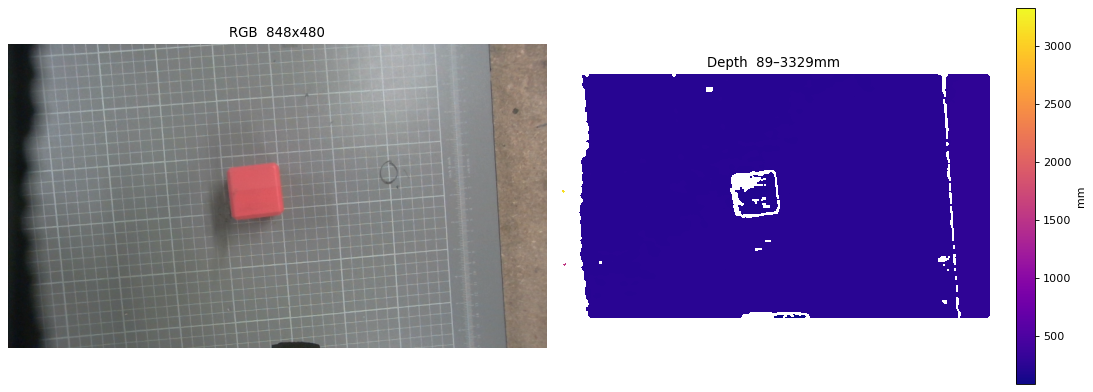

In [7]:
node.spin(12)
color = node.color.copy()
depth = node.depth.copy()

d = depth.astype(float); d[d == 0] = np.nan
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
a1.imshow(color); a1.set_title(f'RGB  {color.shape[1]}x{color.shape[0]}'); a1.axis('off')
im = a2.imshow(d, cmap='plasma'); plt.colorbar(im, ax=a2, label='mm')
a2.set_title(f'Depth  {np.nanmin(d):.0f}–{np.nanmax(d):.0f}mm'); a2.axis('off')
plt.tight_layout(); plt.show()

---
## 4. Object Detection
### 4a. ViT — OWL-ViT

Loading weights:   0%|          | 0/412 [00:00<?, ?it/s]

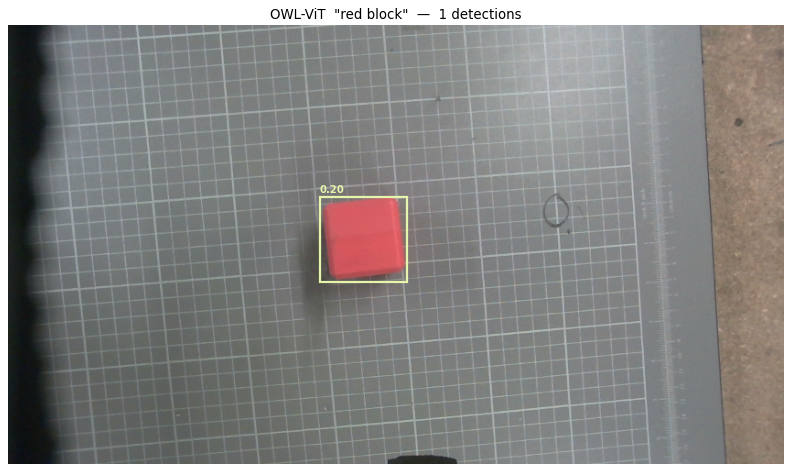

In [8]:
try:
    import torch
    from PIL import Image as PIL_Image
    from transformers import OwlViTProcessor, OwlViTForObjectDetection

    proc = OwlViTProcessor.from_pretrained('google/owlvit-base-patch32')
    mdl  = OwlViTForObjectDetection.from_pretrained('google/owlvit-base-patch32').eval()
    inp  = proc(text=[[OBJECT, f'a {OBJECT}']], images=PIL_Image.fromarray(color),
                return_tensors='pt')
    with torch.no_grad():
        out = mdl(**inp)
    # post_process is on the image_processor, not the wrapper
    results = proc.image_processor.post_process_object_detection(
        out, threshold=0.05, target_sizes=torch.tensor([color.shape[:2]]))[0]
    vb = results['boxes'].numpy()
    vs = results['scores'].numpy()

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(color)
    for b, s in zip(vb, vs):
        x1, y1, x2, y2 = b
        c = plt.cm.YlGn(float(s))
        ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1, lw=2, ec=c, fc='none'))
        ax.text(x1, y1-5, f'{s:.2f}', color=c, fontsize=9, fontweight='bold')
    ax.set_title(f'OWL-ViT  "{OBJECT}"  —  {len(vb)} detections'); ax.axis('off')
    plt.tight_layout(); plt.show()

except ImportError as e:
    print(f'SKIP: {e}  — run: pip install transformers torch')

### 4b. VLM — Gemini: Auto-Detect vs Specified

Auto-detect: "red cube"  |  Using: "red block"


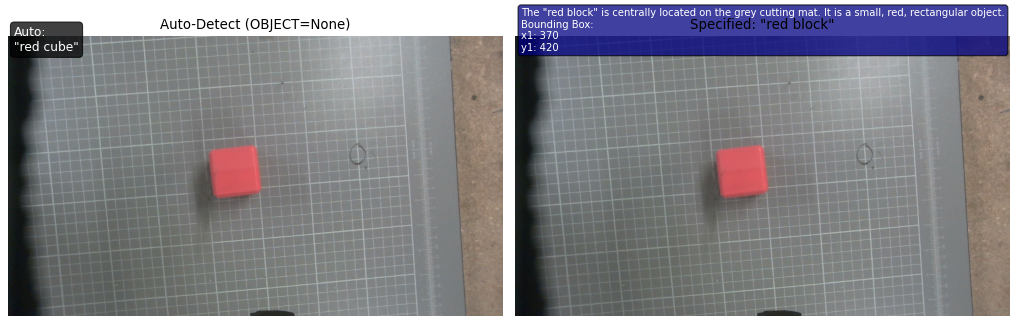

In [9]:
_, buf = cv2.imencode('.jpg', cv2.cvtColor(color, cv2.COLOR_RGB2BGR))
gc = genai.Client(api_key=GEMINI_KEY)

# Auto-detect: ask Gemini to name the main object
r_auto = gc.models.generate_content(
    model='gemini-2.5-flash',
    contents=[
        gtypes.Part.from_bytes(data=buf.tobytes(), mime_type='image/jpeg'),
        'What is the main graspable object in this image? Reply 2-4 words only, no punctuation.'
    ])
auto_obj = r_auto.text.strip().lower()
auto_obj = ' '.join(auto_obj.split()[:4])
ACTIVE   = OBJECT if OBJECT else auto_obj
print(f'Auto-detect: "{auto_obj}"  |  Using: "{ACTIVE}"')

# Specified: ask for bounding box
r_spec = gc.models.generate_content(
    model='gemini-2.5-flash',
    contents=[
        gtypes.Part.from_bytes(data=buf.tobytes(), mime_type='image/jpeg'),
        f'Locate "{ACTIVE}": describe position and give bounding box x1,y1,x2,y2. Graspable yes/no.'
    ])
lines = [l for l in r_spec.text.strip().split('\n') if l.strip()][:4]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
a1.imshow(color)
a1.text(10, 25, f'Auto:\n"{auto_obj}"', color='white', fontsize=11,
        bbox=dict(boxstyle='round', fc='black', alpha=0.75))
a1.set_title('Auto-Detect (OBJECT=None)'); a1.axis('off')
a2.imshow(color)
a2.text(10, 25, '\n'.join(lines), color='white', fontsize=9,
        bbox=dict(boxstyle='round', fc='navy', alpha=0.75))
a2.set_title(f'Specified: "{ACTIVE}"'); a2.axis('off')
plt.tight_layout(); plt.show()

### 4c. SAM3 — Socket (Warm)

Socket  1.28s  score=0.932  mask_px=6807


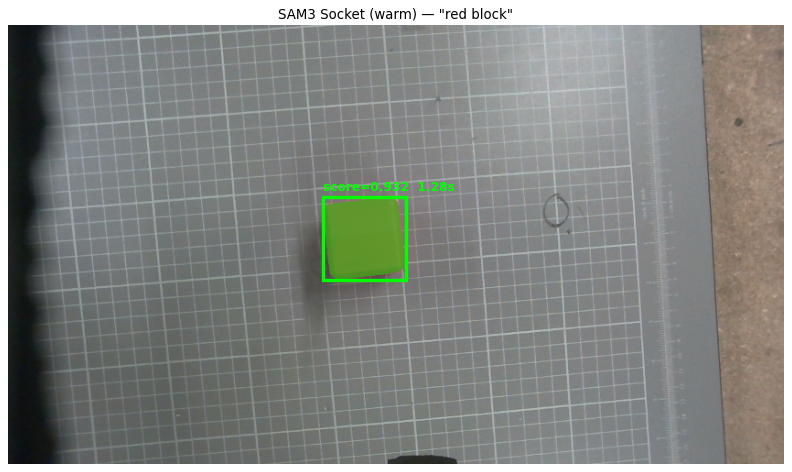

In [10]:
def sam3_query(img_rgb, query, sock_path=SAM3_SOCK):
    tmp = tempfile.mktemp(suffix='.jpg')
    cv2.imwrite(tmp, cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
    try:
        with _sock.socket(_sock.AF_UNIX, _sock.SOCK_STREAM) as s:
            s.connect(sock_path)
            s.sendall((json.dumps({'image': tmp, 'query': query}) + '\n').encode())
            raw = b''
            while True:
                chunk = s.recv(65536)
                if not chunk: break
                raw += chunk
        d = json.loads(raw.decode().strip())
        if 'error' in d: raise RuntimeError(d['error'])
        boxes  = np.array(d['boxes'],  dtype=float)
        scores = np.array(d['scores'], dtype=float)
        mask   = None
        if d.get('mask_b64') and len(boxes) > 0:
            raw2 = base64.b64decode(d['mask_b64'])
            h, w = d['mask_shape']
            mask = np.frombuffer(raw2, dtype=np.uint8).reshape(h, w).astype(bool)
        return boxes, scores, mask
    finally:
        if os.path.exists(tmp): os.unlink(tmp)

t0 = time.time()
sb, ss, sm = sam3_query(color, ACTIVE)
t_sock = time.time() - t0
if len(ss) == 0:
    print(f'Socket  {t_sock:.2f}s  NO DETECTION for "{ACTIVE}"')
else:
    best = int(np.argmax(ss))
    print(f'Socket  {t_sock:.2f}s  score={ss[best]:.3f}  mask_px={sm.sum() if sm is not None else 0}')

best_boxes = sb; best_scores = ss; best_mask = sm

if len(ss) > 0:
    vis = color.copy()
    if sm is not None:
        vis[sm] = (vis[sm] * .45 + np.array([0, 200, 0]) * .55).astype(np.uint8)
    x1, y1, x2, y2 = sb[best].astype(int)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(vis)
    ax.add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1, lw=3, ec='lime', fc='none'))
    ax.text(x1, y1-8, f'score={ss[best]:.3f}  {t_sock:.2f}s', color='lime', fontsize=11, fontweight='bold')
    ax.set_title(f'SAM3 Socket (warm) — "{ACTIVE}"'); ax.axis('off')
    plt.tight_layout(); plt.show()

### 4d. SAM3 — Cold Start

Killing warm server to free VRAM...
Waiting 8s for CUDA to release...
Starting cold...
Loaded in 14s
Infer  1.24s  score=0.932


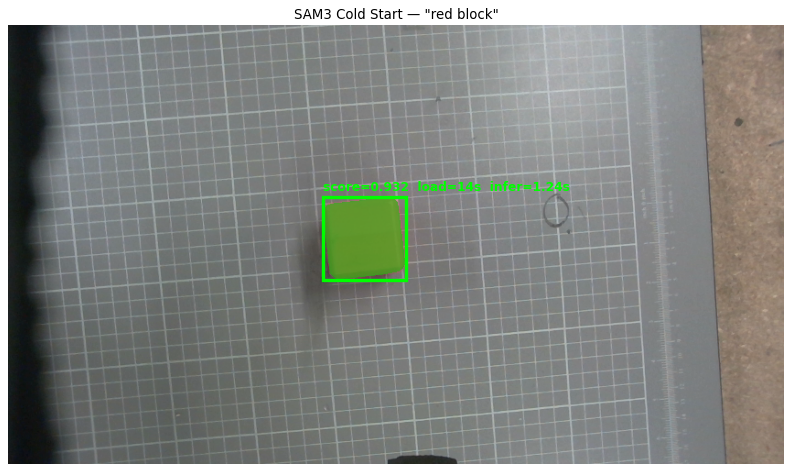


Restarting warm server...
Warm server ready after 14s


In [11]:
COLD_SOCK = '/tmp/sam3_cold.sock'

# Kill warm server to free VRAM, then load cold
print('Killing warm server to free VRAM...')
subprocess.run('pkill -9 -f sam3_infer', shell=True)
subprocess.run(f'rm -f {COLD_SOCK} /tmp/sam3.sock', shell=True)
print('Waiting 8s for CUDA to release...'); time.sleep(8)

print('Starting cold...')
t1 = time.time()
cold_proc = subprocess.Popen(
    [SAM3_PY, SAM3_SCR, '--socket', COLD_SOCK],
    stdout=open('/tmp/log_sam3cold.txt', 'w'), stderr=subprocess.STDOUT)

cold_ok = False; t_load = t_infer = 0
cb, cs, cm = np.zeros((0,4)), np.array([]), None
for i in range(90):
    time.sleep(1)
    if os.path.exists(COLD_SOCK):
        t_load = time.time()-t1; cold_ok = True
        print(f'Loaded in {t_load:.0f}s'); break
    if cold_proc.poll() is not None:
        print('Crashed:'); print(open('/tmp/log_sam3cold.txt').read()[-400:]); break
    if (i+1) % 15 == 0: print(f'  {i+1}s...')

if cold_ok:
    t2 = time.time()
    cb, cs, cm = sam3_query(color, ACTIVE, COLD_SOCK)
    t_infer = time.time()-t2
    best2 = int(np.argmax(cs)) if len(cs) > 0 else 0
    print(f'Infer  {t_infer:.2f}s  score={cs[best2]:.3f}')

    vis = color.copy()
    if cm is not None:
        vis[cm] = (vis[cm]*.45 + np.array([0,200,0])*.55).astype(np.uint8)
    x1,y1,x2,y2 = cb[best2].astype(int)
    fig, ax = plt.subplots(figsize=(10,6))
    ax.imshow(vis)
    ax.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,lw=3,ec='lime',fc='none'))
    ax.text(x1,y1-8,f'score={cs[best2]:.3f}  load={t_load:.0f}s  infer={t_infer:.2f}s',
            color='lime',fontsize=11,fontweight='bold')
    ax.set_title(f'SAM3 Cold Start — "{ACTIVE}"'); ax.axis('off')
    plt.tight_layout(); plt.show()

# Restart warm server for downstream cells
cold_proc.terminate()
subprocess.run(f'rm -f {COLD_SOCK}', shell=True)
print('\nRestarting warm server...')
PROCS['sam3'] = subprocess.Popen(
    [SAM3_PY, SAM3_SCR, '--socket'],
    stdout=open('/tmp/log_sam3.txt','w'), stderr=subprocess.STDOUT)
for i in range(90):
    time.sleep(1)
    if os.path.exists(SAM3_SOCK): print(f'Warm server ready after {i+1}s'); break
    if PROCS['sam3'].poll() is not None: print('Crashed'); break
    if (i+1) % 15 == 0: print(f'  {i+1}s...')

---
## 5. Segmented Point Cloud

In [ ]:
import importlib, pointcloud_utils; importlib.reload(pointcloud_utils)
from pointcloud_utils import build_segmented_pcd, denoise_pcd, analyse_pcd, check_view_quality
import open3d as o3d

node.spin(5)
snap_color  = node.color.copy()
snap_depth  = node.depth.copy()
snap_tcp    = node.tcp.copy()
snap_ci     = node.caminfo
home_scan   = snap_tcp.copy()   # remember home to return after scanning

if 'best_mask' not in dir() or best_mask is None or not best_mask.any():
    print('Re-querying SAM3...')
    best_boxes, best_scores, best_mask = sam3_query(snap_color, ACTIVE)

_fx, _fy = snap_ci.k[0], snap_ci.k[4]
_cx, _cy = snap_ci.k[2], snap_ci.k[5]

# ── Scan 1: home (angled side view) ──────────────────────────────────────────
pts_raw1, pcd_raw1 = build_segmented_pcd(
    best_mask, snap_depth, snap_ci.k, snap_tcp, _TCP_TO_CAM)
_ys1, _xs1 = np.where(best_mask)
_u1, _v1   = int(_xs1.mean()), int(_ys1.mean())
_vd1 = snap_depth[best_mask].astype(float); _vd1 = _vd1[_vd1 > 0]
_dm1 = float(np.median(_vd1)) / 1000. if len(_vd1) > 0 else 0.
_hint1 = (snap_tcp @ _TCP_TO_CAM @ np.array([
    (_u1-_cx)*_dm1/_fx, (_v1-_cy)*_dm1/_fy, _dm1, 1.]))[:3]
pcd_cln1, pts_cln1 = denoise_pcd(pcd_raw1, hint=_hint1)
vq1 = check_view_quality(pts_cln1, best_mask, snap_depth)
print(f'Scan 1 (home, side): {vq1["n_pts"]} pts  fill={vq1["fill"]:.0%}  '
      f'{"OK" if vq1["ok"] else "BLOCKED: " + vq1["reason"]}')

# Quick p_world from scan 1 — used to position arm for top-down scan
_p_cam1   = np.array([(_u1-_cx)*_dm1/_fx, (_v1-_cy)*_dm1/_fy, _dm1])
_p_world1 = (snap_tcp @ _TCP_TO_CAM @ np.array([*_p_cam1, 1.]))[:3]

# ── Scan 2: directly above the object (top-down) ─────────────────────────────
tcp2 = snap_tcp.copy()
tcp2[0, 3] = _p_world1[0]
tcp2[1, 3] = _p_world1[1]
tcp2[2, 3] = _p_world1[2] + APPROACH_H + GRIPPER_LEN
node.move(tcp2, spd=0.08); node.spin(4)
color2 = node.color.copy(); depth2 = node.depth.copy()

_, _, mask2 = sam3_query(color2, ACTIVE)
if mask2 is None or not mask2.any():
    mask2 = best_mask

pts_raw2, pcd_raw2 = build_segmented_pcd(mask2, depth2, snap_ci.k, tcp2, _TCP_TO_CAM)
_ys2, _xs2 = np.where(mask2)
_u2, _v2   = int(_xs2.mean()), int(_ys2.mean())
_vd2 = depth2[mask2].astype(float); _vd2 = _vd2[_vd2 > 0]
_dm2 = float(np.median(_vd2)) / 1000. if len(_vd2) > 0 else 0.
_hint2 = (tcp2 @ _TCP_TO_CAM @ np.array([
    (_u2-_cx)*_dm2/_fx, (_v2-_cy)*_dm2/_fy, _dm2, 1.]))[:3]
pcd_cln2, pts_cln2 = denoise_pcd(pcd_raw2, hint=_hint2)
vq2 = check_view_quality(pts_cln2, mask2, depth2)
print(f'Scan 2 (above, top): {vq2["n_pts"]} pts  fill={vq2["fill"]:.0%}  '
      f'{"OK" if vq2["ok"] else "BLOCKED: " + vq2["reason"]}')

# ── Merge ─────────────────────────────────────────────────────────────────────
good_pts = []
if vq1['ok']: good_pts.append(pts_cln1)
if vq2['ok']: good_pts.append(pts_cln2)
if not good_pts:
    good_pts = [pts_cln1 if vq1['n_pts'] >= vq2['n_pts'] else pts_cln2]
    print('WARNING: both scans blocked — using best available')

merged_raw = np.vstack(good_pts)
pcd_merge  = o3d.geometry.PointCloud()
pcd_merge.points = o3d.utility.Vector3dVector(merged_raw)
pcd_cln, pts_cln = denoise_pcd(pcd_merge)

src = ('scan1+scan2' if vq1['ok'] and vq2['ok']
       else 'scan2 only' if vq2['ok'] else 'scan1 only')
print(f'Merged [{src}]: {len(merged_raw)} raw → {len(pts_cln)} clean pts')

# snap_tcp = tcp2 so downstream depth centroid uses top-down camera transform
snap_color = color2; snap_depth = depth2; snap_tcp = tcp2; best_mask = mask2

# Return arm to home
node.move(home_scan, spd=0.08); node.spin(3)
print('Arm returned home.')

fig = plt.figure(figsize=(17, 5))
ax1 = fig.add_subplot(131, projection='3d')
sc = ax1.scatter(pts_cln[:, 0], pts_cln[:, 1], pts_cln[:, 2],
                 c=pts_cln[:, 2], cmap='plasma', s=4, alpha=.7)
plt.colorbar(sc, ax=ax1, label='Z m', shrink=.7)
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
ax1.set_title(f'Merged [{src}]  {len(pts_cln)} pts')
ax2 = fig.add_subplot(132)
vis1 = snap_color.copy()
if best_mask is not None:
    vis1[best_mask] = (vis1[best_mask] * .4 + np.array([0, 180, 0]) * .6).astype(np.uint8)
ax2.imshow(vis1); ax2.set_title('Scan 2 mask (top-down)'); ax2.axis('off')
ax3 = fig.add_subplot(133)
ax3.scatter(pts_cln[:, 0], pts_cln[:, 1], c=pts_cln[:, 2], cmap='plasma', s=5, alpha=.6)
ax3.set_xlabel('X m'); ax3.set_ylabel('Y m'); ax3.set_title('Top-down (XY)')
ax3.set_aspect('equal')
plt.tight_layout(); plt.show()

---
## 6. 3D Centroid / 6D Pose

Pixel  : (388, 233)
Depth  : 204.0 mm
Camera : [-0.016 -0.002  0.204]
World  : x=-0.1969  y=-0.6149  z=0.0722 m


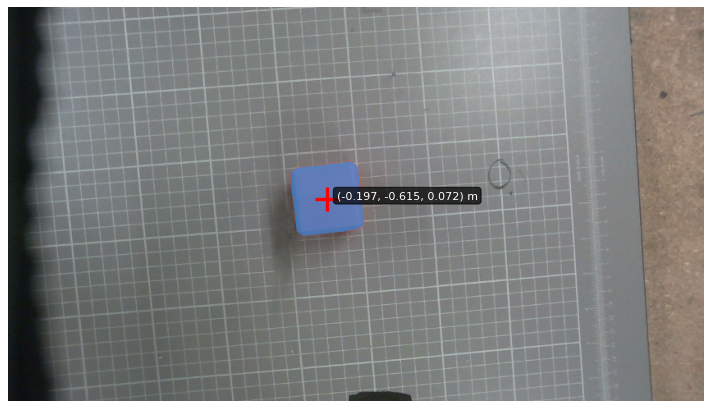

In [13]:
if best_mask is not None and best_mask.any():
    ys, xs = np.where(best_mask)
    u, v   = int(xs.mean()), int(ys.mean())
    valid  = snap_depth[best_mask].astype(float)
    valid  = valid[valid > 0]
else:
    h, w = snap_depth.shape
    u, v = w // 2, h // 2
    valid = np.array([])

dm = float(np.median(valid)) / 1000. if len(valid) > 0 else 0.
fx, fy = snap_ci.k[0], snap_ci.k[4]
cx, cy = snap_ci.k[2], snap_ci.k[5]
p_cam   = np.array([(u - cx) * dm / fx, (v - cy) * dm / fy, dm])
T       = snap_tcp @ _TCP_TO_CAM
p_world = (T @ np.array([*p_cam, 1.]))[:3]

# Measure TABLE_Z from depth pixels adjacent to the mask
import cv2 as _cv2
dilated   = _cv2.dilate(best_mask.astype(np.uint8), np.ones((30,30),np.uint8)).astype(bool)
tbl_mask  = dilated & ~best_mask
tbl_valid = snap_depth[tbl_mask].astype(float)
tbl_valid = tbl_valid[tbl_valid > 0]
if len(tbl_valid) > 50:
    tbl_dm   = float(np.median(tbl_valid)) / 1000.
    tys, txs = np.where(tbl_mask)
    tu, tv   = int(txs.mean()), int(tys.mean())
    p_tbl    = np.array([(tu-cx)*tbl_dm/fx, (tv-cy)*tbl_dm/fy, tbl_dm])
    TABLE_Z  = float((T @ np.array([*p_tbl, 1.]))[2])
    obj_height_est = max(p_world[2] - TABLE_Z, 0.005)
    auto_offset    = float(np.clip(obj_height_est / 2., 0.005, 0.040))
    print(f'TABLE_Z measured : {TABLE_Z*1000:.1f} mm')
    print(f'Object height est: {obj_height_est*1000:.1f} mm')
else:
    TABLE_Z        = HARD_FLOOR_Z
    obj_height_est = 0.020
    auto_offset    = 0.010
    print('TABLE_Z: could not measure — using HARD_FLOOR_Z fallback')

print(f'Pixel  : ({u}, {v})')
print(f'Depth  : {dm*1000:.1f} mm')
print(f'Camera : {p_cam}')
print(f'World  : x={p_world[0]:.4f}  y={p_world[1]:.4f}  z={p_world[2]:.4f} m')
print(f'Grasp offset: {auto_offset*1000:.1f} mm  (grip at middle of {obj_height_est*1000:.1f}mm object)')

fig, ax = plt.subplots(figsize=(9, 6))
vis = snap_color.copy()
if best_mask is not None:
    vis[best_mask] = (vis[best_mask] * .45 + np.array([0, 150, 255]) * .55).astype(np.uint8)
ax.imshow(vis)
ax.plot(u, v, 'r+', ms=22, mew=3)
ax.text(u + 12, v, f'({p_world[0]:.3f}, {p_world[1]:.3f}, {p_world[2]:.3f}) m',
        color='white', fontsize=10, bbox=dict(boxstyle='round', fc='black', alpha=.7))
ax.axis('off'); plt.tight_layout(); plt.show()

---
## 7. PCA + Gripper Alignment

In [ ]:
from pointcloud_utils import smart_grasp_angle, top_layer

# Use top layer for angle only — strips mat grid / table noise
pts_top = top_layer(pts_cln)
pca = analyse_pcd(pts_top)
cen = pca['centroid']
ext = pca['extent_m']
obj_height  = ext[2]
auto_offset = float(np.clip(obj_height / 4., 0.005, 0.015))

ang, strategy, reason = smart_grasp_angle(
    pca, object_name=ACTIVE, image_rgb=snap_color,
    gemini_client=gc if 'gc' in dir() else None,
    mask=best_mask)

print(f'Extent  major={ext[0]*1e3:.1f}mm  minor={ext[1]*1e3:.1f}mm  normal={ext[2]*1e3:.1f}mm')
print(f'Grasp angle:   {ang:.1f} deg  [{strategy}]  {reason}')
print(f'Auto offset:   {auto_offset*1e3:.0f} mm  (height/4, clamped 5-15mm)')
print(f'top_layer:     {len(pts_top)}/{len(pts_cln)} pts for angle; full cloud for position')

ptc  = pts_cln - cen
ev, evec = np.linalg.eigh(np.cov(ptc.T))
idx  = np.argsort(ev)[::-1]; evec = evec[:, idx]; sc = np.sqrt(np.abs(ev[idx]))

fig = plt.figure(figsize=(13, 6))
ax  = fig.add_subplot(121, projection='3d')
ax.scatter(pts_cln[:, 0], pts_cln[:, 1], pts_cln[:, 2],
           c=pts_cln[:, 2], cmap='plasma', s=4, alpha=.4)
for i, (lbl, col) in enumerate(zip(['Major', 'Minor', 'Normal'], ['red', 'green', 'blue'])):
    vec = evec[:, i] * sc[i]
    ax.quiver(*cen, *vec, color=col, label=f'{lbl} {sc[i]*1e3:.0f}mm', lw=2.5)
ax.scatter(*cen, color='yellow', s=120, zorder=5)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title(f'PCA  angle={ang:.1f}deg'); ax.legend(fontsize=9)

ax2 = fig.add_subplot(122)
ax2.scatter(pts_cln[:, 0], pts_cln[:, 1], c=pts_cln[:, 2], cmap='plasma', s=5, alpha=.5)
t = np.radians(ang); L = sc[0]
ax2.annotate('', xy=(cen[0]+L*np.cos(t), cen[1]+L*np.sin(t)),
             xytext=(cen[0]-L*np.cos(t), cen[1]-L*np.sin(t)),
             arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax2.annotate('', xy=(cen[0]+L*np.cos(t+np.pi/2), cen[1]+L*np.sin(t+np.pi/2)),
             xytext=cen[:2],
             arrowprops=dict(arrowstyle='->', color='lime', lw=2))
ax2.set_aspect('equal'); ax2.set_xlabel('X m'); ax2.set_ylabel('Y m')
ax2.set_title('Top-down: major axis + gripper approach')
plt.tight_layout(); plt.show()

---
## 8. Move Arm to Computed Pose

In [ ]:
from pointcloud_utils import grasp_rotation_matrix

# After the two-scan c09, snap_tcp is already above the object — use it as the base.
# Fall back to home if c09 hasn't been run in this session.
_base = snap_tcp if 'snap_tcp' in dir() else home

ap = _base.copy()
ap[0, 3] = p_world[0]
ap[1, 3] = p_world[1]
ap[2, 3] = p_world[2] + APPROACH_H + GRIPPER_LEN

afz      = p_world[2] + APPROACH_H
gfz      = p_world[2] - auto_offset
ok_a = afz >= HARD_FLOOR_Z
ok_g = gfz >= HARD_FLOOR_Z
print(f'Approach fingertip z : {afz:.4f} m  {"OK" if ok_a else "FLOOR HIT"}')
print(f'Grasp fingertip z    : {gfz:.4f} m  {"OK" if ok_g else "FLOOR HIT"}')
print(f'Safety check         : {"PASS" if ok_a and ok_g else "FAIL"}')

if ok_a and ok_g:
    node.unteach()

    print(f'\nMoving to approach (TCP z={ap[2,3]:.3f} m)...')
    node.move(ap, spd=0.08)
    time.sleep(0.5); node.spin(5)
    cur = poses.pose_mtrx_to_vec(node.tcp)
    print(f'At approach: x={cur[0]:.3f} y={cur[1]:.3f} z={cur[2]:.3f}')

    R_grasp = grasp_rotation_matrix(ang)
    ap_rot = ap.copy()
    ap_rot[:3, :3] = R_grasp
    print(f'\nApplying PCA rotation ({ang:.1f} deg)...')
    node.move(ap_rot, spd=0.05)
    time.sleep(0.5); node.spin(5)
    cur2 = poses.pose_mtrx_to_vec(node.tcp)
    print(f'After rotation: x={cur2[0]:.3f} y={cur2[1]:.3f} z={cur2[2]:.3f}')

    node.move(home if 'home' in dir() else snap_tcp, spd=0.08); print('\nHome.')
else:
    print('Move skipped (safety).')

---
## 9. Gripper Tool Length

In [ ]:
# Effective grasp Z — no arc correction (simplified safety check)
gez  = gfz
drop = 0.

print(f'TCP flange z (command) = {ap[2,3]:.4f} m')
print(f'GRIPPER_LEN            = {GRIPPER_LEN:.3f} m')
print(f'Fingertip at approach  = {afz:.4f} m  (= TCP - {GRIPPER_LEN})')
print(f'Grasp fingertip        = {gfz:.4f} m  (p_world[2] - auto_offset)')
print(f'Arc drop at full close = {drop*1000:.1f} mm  (not corrected — simplified check)')

items = [
    ('TCP flange',   ap[2, 3],    'royalblue'),
    ('Fingertip',    afz,         'limegreen'),
    ('Object top',   p_world[2],  'orange'),
    ('Grasp tip',    gfz,         'gold'),
    ('Eff. grasp z', gez,         'magenta'),
    ('Floor',        HARD_FLOOR_Z, 'saddlebrown'),
]
fig, ax = plt.subplots(figsize=(8, 5))
for i, (lbl, z, col) in enumerate(items):
    ax.barh(i, z, color=col, alpha=.85)
    ax.text(z + .002, i, f'{z:.3f} m', va='center')
ax.set_yticks(range(len(items))); ax.set_yticklabels([it[0] for it in items])
ax.axvline(HARD_FLOOR_Z, color='red', ls='--', lw=1.5, label='Safety floor')
ax.set_xlabel('m'); ax.set_title('Tool Length Accounting'); ax.legend()
plt.tight_layout(); plt.show()

---
## 10. DeliGrasp Parameters (Gemini)

DeliGrasp — "red block"
  Mass        200 g
  Stiffness k 20000 N/m
  Friction μ  0.60


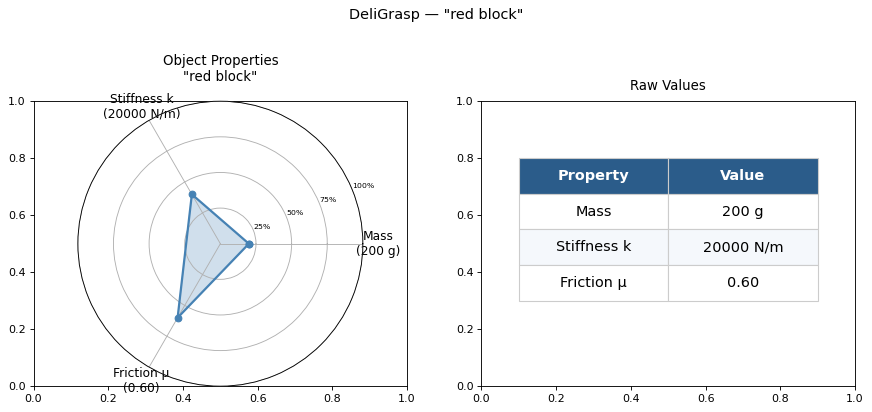

In [20]:
DG_SYS = (
    'Control a robot gripper. Max 16N min 0.15N, max aperture 105mm min 1mm.\n'
    'Rules: replace [PNUM] with a positive number, {CHOICE:[a,b]} with one choice.\n'
    'Spring constant must be between 20 N/m (very soft/squishy) and 2000 N/m (hard rubber/stiff plastic). Assess from the image.\n'
    'Always output [start of description] and [end of description] tags.\n'
    '[start of description]\n'
    '* This is a new grasp.\n'
    '* In accordance with the user instruction, this grasp should be [GRASP_DESCRIPTION].\n'
    '* This is a complete grasp.\n'
    '* This grasp does not contain multiple grasps.\n'
    '* This grasp is for an object with {CHOICE:[high,medium,low]} weight.\n'
    '* The object has an approximate mass of [PNUM] grams\n'
    '* This grasp is for an object with {CHOICE:[high,medium,low]} compliance.\n'
    '* The object has an approximate spring constant of [PNUM] Newtons per meter.\n'
    '* The gripper and object have an approximate friction coefficient of [PNUM]\n'
    '* This grasp should set the goal aperture to [PNUM] mm.\n'
    '* If the gripper slips, this grasp should close an additional [PNUM] mm.\n'
    '* If the gripper slips, this grasp should increase the output force by [PNUM] Newtons.\n'
    '[end of description]')

_, _buf = cv2.imencode('.jpg', cv2.cvtColor(
    snap_color if 'snap_color' in dir() else color, cv2.COLOR_RGB2BGR))
raw_dg = gc.models.generate_content(
    model='gemini-2.5-flash',
    contents=[
        gtypes.Part.from_bytes(data=_buf.tobytes(), mime_type='image/jpeg'),
        (f'Pick up the {ACTIVE}. '
         f'Look at the image carefully to assess material and compliance. '
         f'Respond using the exact template format, replacing all [PNUM] fields with numbers.'),
    ],
    config=gtypes.GenerateContentConfig(system_instruction=DG_SYS)).text

NUM = r'([0-9]+(?:\.[0-9]+)?)'

def parse_dg(txt):
    m = re.search(r'\[start of description\](.*?)\[end of description\]',
                  txt, re.DOTALL | re.IGNORECASE)
    b = m.group(1) if m else txt
    def g(pat):
        h = re.search(pat, b, re.IGNORECASE)
        return float(h.group(1)) if h else None
    mass = g(rf'mass of {NUM} grams')
    k    = g(rf'spring constant of {NUM} Newtons')
    mu   = g(rf'friction coefficient of {NUM}')
    ap2  = g(rf'goal aperture to {NUM} mm')
    cl   = g(rf'close an additional {NUM} mm')
    af   = g(rf'output force by {NUM} Newtons')
    fi        = min(16., max(0.15, (mass / 1000 * 9.81) / max(mu, 1e-6))) if mass and mu else 3.
    force_cap = float(np.clip((k or 1000.) * 0.008, 1.0, 16.))  # F=k*deformation, ~8mm allowable
    fi        = min(fi, force_cap)
    return dict(mass_g=mass, k=k, mu=mu, aperture_mm=ap2, closure_mm=cl,
                initial_force=fi, force_cap=force_cap,
                add_force=af or max(0.05, (cl or 5.) * (k or 100.) * .0001))

GP = parse_dg(raw_dg)

# ── Search-grounded override: look up REAL object specs online ──────────────────
try:
    _search_tool = gtypes.Tool(google_search=gtypes.GoogleSearch())
    _lookup = gc.models.generate_content(
        model='gemini-2.5-flash',
        contents=[
            gtypes.Part.from_bytes(data=_buf.tobytes(), mime_type='image/jpeg'),
            (f'The object in this image is a "{ACTIVE}". Search the web for its real '
             f'specifications. A two-finger robot gripper with rubber pads must lift it. '
             f'Report ONLY these three lines with numbers:\n'
             f'MASS_G: <realistic mass in grams from web specs>\n'
             f'FRICTION: <static friction vs rubber pad: 0.25 smooth metal/plastic, '
             f'0.5 hard plastic, 0.8 soft rubber/fabric>\n'
             f'STIFFNESS: <N/m: 20 soft foam, 500 rubber, 2000 rigid plastic/metal>'),
        ],
        config=gtypes.GenerateContentConfig(tools=[_search_tool])).text
    _sm = re.search(rf'MASS_G:\s*{NUM}', _lookup, re.I)
    _sf = re.search(rf'FRICTION:\s*{NUM}', _lookup, re.I)
    _sk = re.search(rf'STIFFNESS:\s*{NUM}', _lookup, re.I)
    if _sm: GP['mass_g'] = float(_sm.group(1))
    if _sf: GP['mu']     = float(np.clip(float(_sf.group(1)), 0.15, 1.0))
    if _sk: GP['k']      = float(np.clip(float(_sk.group(1)), 20., 2000.))
    # Recompute force policy from grounded physics
    GP['initial_force'] = min(16., max(0.15, (GP['mass_g']/1000.*9.81)/max(GP['mu'],1e-6)))
    GP['force_cap']     = float(np.clip(GP['k'] * 0.008, 1.0, 16.))
    print(f'  [search-grounded] mass={GP["mass_g"]:.0f}g  mu={GP["mu"]:.2f}  k={GP["k"]:.0f}N/m  -> F_min={(GP["mass_g"]/1000.*9.81)/(2*GP["mu"]):.2f}N  cap={GP["force_cap"]:.1f}N')
except Exception as e:
    print(f'  [search grounding failed: {e} — using image-only estimate]')
print(f'DeliGrasp — "{ACTIVE}"')
print(f'  Mass        {GP["mass_g"]:.0f} g')
print(f'  Stiffness k {GP["k"]:.0f} N/m')
print(f'  Friction μ  {GP["mu"]:.2f}')

# Radar chart — normalize each property to [0,1] relative to reference max
MAX_MASS = 1000.   # g  (very heavy object)
MAX_K    = 50000.  # N/m (very stiff object)
MAX_MU   = 1.0     # (max friction)

labels   = ['Mass', 'Stiffness k', 'Friction μ']
vals     = [GP['mass_g']/MAX_MASS, GP['k']/MAX_K, GP['mu']/MAX_MU]
raw_vals = [f"{GP['mass_g']:.0f} g", f"{GP['k']:.0f} N/m", f"{GP['mu']:.2f}"]

# Close the polygon
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]
vals_plot = vals + vals[:1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5),
                                subplot_kw=dict(polar=True) if False else {})
# Left: radar
ax1 = fig.add_subplot(121, polar=True)
ax1.plot(angles, vals_plot, 'o-', lw=2, color='steelblue')
ax1.fill(angles, vals_plot, alpha=0.25, color='steelblue')
ax1.set_xticks(angles[:-1])
ax1.set_xticklabels([f'{l}\n({v})' for l, v in zip(labels, raw_vals)], fontsize=11)
ax1.set_ylim(0, 1); ax1.set_yticks([0.25, 0.5, 0.75, 1.0])
ax1.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=7)
ax1.set_title(f'Object Properties\n"{ACTIVE}"', pad=18)

# Right: clean value table as text
ax2 = fig.add_subplot(122)
ax2.axis('off')
table_data = [[l, v] for l, v in zip(labels, raw_vals)]
tbl = ax2.table(cellText=table_data, colLabels=['Property', 'Value'],
                cellLoc='center', loc='center',
                bbox=[0.1, 0.3, 0.8, 0.5])
tbl.auto_set_font_size(False); tbl.set_fontsize(13)
tbl.scale(1, 2)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#cccccc')
    if r == 0:
        cell.set_facecolor('#2b5c8a'); cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#f5f8fc' if r % 2 == 0 else 'white')
ax2.set_title('Raw Values', fontsize=12, pad=10)

plt.suptitle(f'DeliGrasp — "{ACTIVE}"', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 11. Adaptive Grasp (Slip Detection)

In [ ]:
# Physics-based force floor: minimum force to hold object against gravity
F_min        = (GP['mass_g'] / 1000. * 9.81) / (2. * GP['mu'])
force_cap    = GP.get('force_cap', 16.)
close_force  = float(np.clip(max(GP['initial_force'], F_min * 1.2, 5.), 5., force_cap))
slip_thresh  = float(max(0.15, min(F_min * 0.9, force_cap * 0.8)))
print(f'F_min={F_min:.2f}N  close={close_force:.1f}N  threshold={slip_thresh:.3f}N')

node.unteach()
node.open_g(); time.sleep(0.5)

# Pre-position gripper to just above object width for faster, more controlled contact
if 'pca' in dir():
    obj_w_mm = pca['extent_m'][1] * 1000.
    pre_ap   = float(np.clip(obj_w_mm + 5., 10., 100.))
    node.set_pos(pre_ap); time.sleep(1.0)
    print(f'Pre-positioned to {pre_ap:.0f}mm (object width {obj_w_mm:.1f}mm)')

log = []
cf  = close_force
for attempt in range(6):
    print(f'Attempt {attempt+1}: force={cf:.2f}N')
    target_ap = GP['aperture_mm'] if GP.get('aperture_mm') else 0.
    node.set_force(cf)
    if target_ap > 1.:
        node.set_pos(target_ap); time.sleep(3.5)
    else:
        node.close_g(); time.sleep(3.5)
    for _ in range(8): rclpy.spin_once(node, timeout_sec=0.15)
    s = node.gs
    if s is None:
        print('  No gripper state'); break
    status = 'contact' if s.force >= slip_thresh else 'slip'
    print(f'  ap={s.position:.1f}mm  F={s.force:.3f}N  target={target_ap:.0f}mm  -> {status}')
    log.append({'attempt': attempt+1, 'force': s.force, 'ap': s.position, 'status': status})
    if status == 'contact':
        break
    deficit = max(0., slip_thresh - s.force)
    cf = min(16., cf + max(GP['add_force'], deficit + 0.5))
    if target_ap > 1.: target_ap = max(1., target_ap - GP.get('closure_mm', 5.))

node.open_g()

if log:
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
    atts = [str(x['attempt']) for x in log]
    cols = ['limegreen' if x['status'] == 'contact' else 'tomato' for x in log]
    a1.bar(atts, [x['force'] for x in log], color=cols)
    a1.axhline(slip_thresh, color='orange', ls='--', lw=2, label=f'threshold {slip_thresh:.2f}N')
    a1.axhline(F_min,       color='cyan',   ls=':',  lw=1.5, label=f'F_min {F_min:.2f}N')
    a1.set_ylabel('N'); a1.set_title('Measured Force'); a1.legend()
    a2.bar(atts, [x['ap'] for x in log], color='steelblue')
    a2.set_ylabel('mm'); a2.set_title('Aperture')
    plt.suptitle(f'Adaptive Grasp — "{ACTIVE}"'); plt.tight_layout(); plt.show()
    last = log[-1]
    print(f'Result: {last["status"]}  ap={last["ap"]:.1f}mm  F={last["force"]:.3f}N  attempts={len(log)}')

---
## Shutdown

In [ ]:
# ── Re-detect — Gemini names the object, SAM3 finds it ──────────────────────
node.spin(5)
snap_color = node.color.copy()
snap_depth = node.depth.copy()
snap_tcp   = node.tcp.copy()
snap_ci    = node.caminfo

_, buf = cv2.imencode('.jpg', cv2.cvtColor(snap_color, cv2.COLOR_RGB2BGR))
r_auto = gc.models.generate_content(
    model='gemini-2.5-flash',
    contents=[
        gtypes.Part.from_bytes(data=buf.tobytes(), mime_type='image/jpeg'),
        'What is the main graspable object? Reply 2-4 words only, no punctuation.'
    ])
ACTIVE = ' '.join(r_auto.text.strip().lower().split()[:4])
print(f'Detected: "{ACTIVE}"')

det_boxes, det_scores, det_mask = sam3_query(snap_color, ACTIVE)
if len(det_scores) == 0 or det_mask is None:
    print(f'SAM3: no detection for "{ACTIVE}"')
else:
    best_i = int(np.argmax(det_scores))
    print(f'score={det_scores[best_i]:.3f}  mask_px={det_mask.sum()}')
    vis = snap_color.copy()
    vis[det_mask] = (vis[det_mask]*.4 + np.array([0,200,0])*.6).astype(np.uint8)
    x1,y1,x2,y2 = det_boxes[best_i].astype(int)
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.imshow(vis)
    ax.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,lw=3,ec='lime',fc='none'))
    ax.set_title(f'SAM3 — "{ACTIVE}"  score={det_scores[best_i]:.3f}'); ax.axis('off')
    plt.tight_layout(); plt.show()

---
## 12. Full Pickup — End-to-End

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
=== Full Pickup ===
Gemini: "red cube"
SAM3:   score=0.919  mask_px=10023


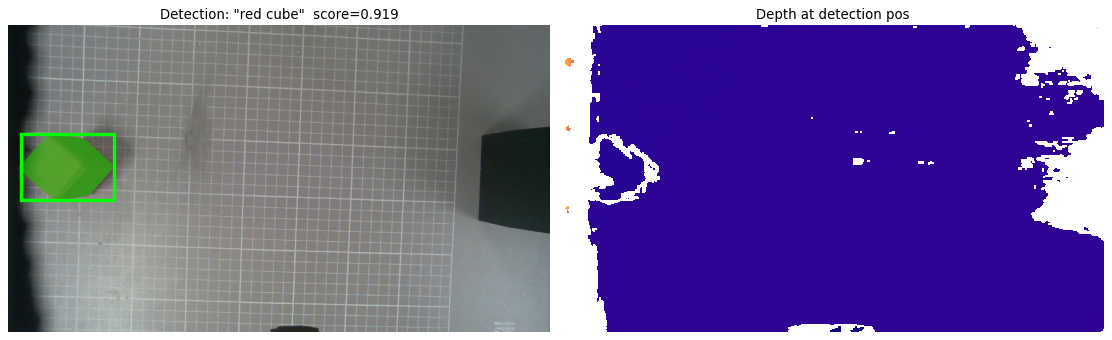

  Rough object position: (-0.207, -0.556, 0.075)
  Scan (top-down): 5344 pts  fill=93%  OK


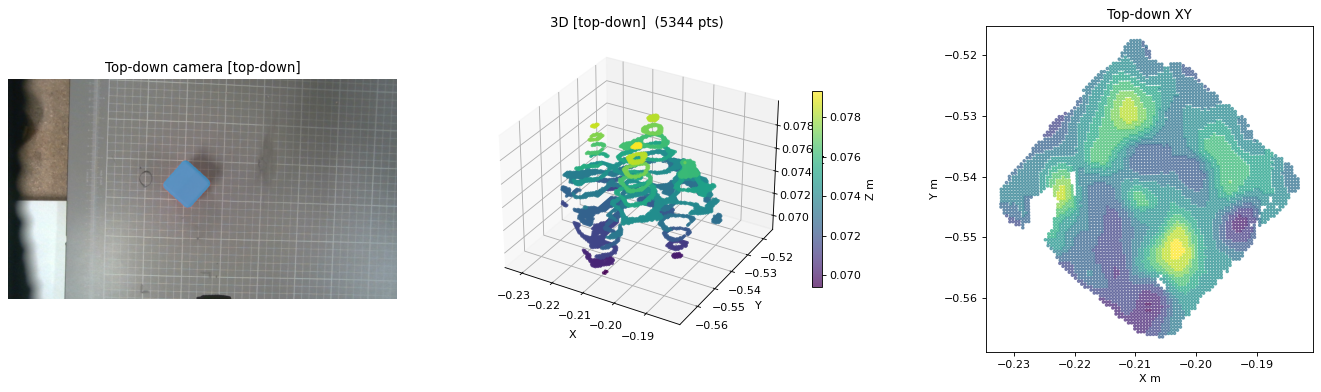

  PCA: major=49.0mm  minor=49.1mm  angle=39.6deg  [symmetric]
  reason: gemini: symmetric (ratio=1.01)


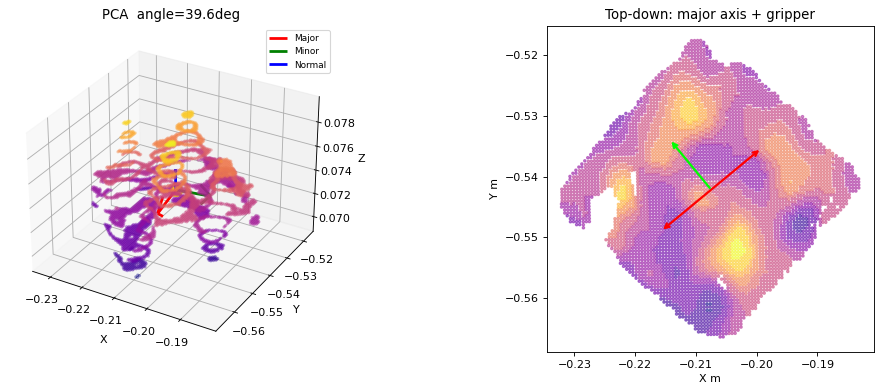

  p_obj=(-0.207,-0.542,0.073)
  TABLE_Z=34.6mm  obj_h=38.7mm  grasp_off=19.4mm
Safety OK  approach_fz=0.173m  grasp_fz=0.054m

Approach (refine)...
PCA rotate...
Descend...
Grasping (force=5.0N  thresh=0.15N  pre_ap=54mm)...
  attempt 1: ap=31.3mm F=2.495N -> contact
Lifting...
Post-lift: F=2.749N  ap=31.7mm  -> HOLDING
Done — object released.


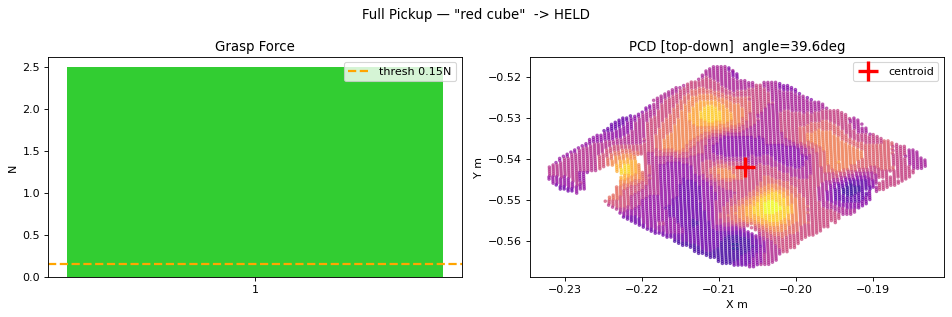


Result: contact  ap=31.3mm  F=2.495N  attempts=1


In [6]:
import importlib, pointcloud_utils; importlib.reload(pointcloud_utils)
from pointcloud_utils import (build_segmented_pcd, denoise_pcd, analyse_pcd,
                              grasp_rotation_matrix, check_view_quality, top_layer,
                              smart_grasp_angle)
import open3d as o3d

print('=== Full Pickup ===')

# Ensure dependencies exist if cells 8b/8c weren't run
if 'gc' not in dir():
    from google import genai
    gc = genai.Client(api_key=os.environ.get('GEMINI_API_KEY', ''))

if 'sam3_query' not in dir():
    import socket as _sock, json, base64, tempfile
    def sam3_query(img_rgb, query, sock_path=SAM3_SOCK):
        tmp = tempfile.mktemp(suffix='.jpg')
        cv2.imwrite(tmp, cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
        try:
            with _sock.socket(_sock.AF_UNIX, _sock.SOCK_STREAM) as s:
                s.connect(sock_path)
                s.sendall((json.dumps({'image': tmp, 'query': query}) + '\n').encode())
                raw = b''
                while True:
                    chunk = s.recv(65536)
                    if not chunk: break
                    raw += chunk
            d = json.loads(raw.decode().strip())
            if 'error' in d: raise RuntimeError(d['error'])
            boxes  = np.array(d['boxes'],  dtype=float)
            scores = np.array(d['scores'], dtype=float)
            mask   = None
            if d.get('mask_b64') and len(boxes) > 0:
                raw2 = base64.b64decode(d['mask_b64'])
                h, w = d['mask_shape']
                mask = np.frombuffer(raw2, dtype=np.uint8).reshape(h, w).astype(bool)
            return boxes, scores, mask
        finally:
            if os.path.exists(tmp): os.unlink(tmp)

# ── 1. Snapshot + Gemini detect ───────────────────────────────────────────────
node.spin(8)
fp_color  = node.color.copy()
fp_depth  = node.depth.copy()
fp_tcp    = node.tcp.copy()
fp_ci     = node.caminfo
home_pick = fp_tcp.copy()

_, _buf = cv2.imencode('.jpg', cv2.cvtColor(fp_color, cv2.COLOR_RGB2BGR))
r_auto = gc.models.generate_content(
    model='gemini-2.5-flash',
    contents=[
        gtypes.Part.from_bytes(data=_buf.tobytes(), mime_type='image/jpeg'),
        'What is the main graspable object? Reply 2-4 words only, no punctuation.'
    ])
ACTIVE = ' '.join(r_auto.text.strip().lower().split()[:4])
if 'ACTIVE_OVERRIDE' in dir() and ACTIVE_OVERRIDE.strip():
    print(f'Gemini detected: "{ACTIVE}" → overridden to "{ACTIVE_OVERRIDE.strip()}"')
    ACTIVE = ACTIVE_OVERRIDE.strip().lower()
else:
    print(f'Gemini detected: "{ACTIVE}"  (set ACTIVE_OVERRIDE="name" to change)')

# ── 2. SAM3 with close-up retry ──────────────────────────────────────────────
MAX_DET_RETRIES = 3
CLOSE_STEP_M    = 0.02
_det_tcp = fp_tcp.copy()
fp_boxes = fp_scores = fp_mask = None

for _det_try in range(1 + MAX_DET_RETRIES):
    fp_boxes, fp_scores, fp_mask = sam3_query(fp_color, ACTIVE)
    if len(fp_scores) > 0 and fp_mask is not None:
        best_i = int(np.argmax(fp_scores))
        print(f'SAM3:   score={fp_scores[best_i]:.3f}  mask_px={fp_mask.sum()}'
              + (f'  (moved {_det_try*CLOSE_STEP_M*100:.0f}cm closer)' if _det_try else ''))
        break
    if _det_try < MAX_DET_RETRIES:
        print(f'  SAM3 try {_det_try+1}: no detection — moving 2cm closer...')
        _det_tcp = _det_tcp.copy(); _det_tcp[2, 3] -= CLOSE_STEP_M
        node.unteach(); node.move(_det_tcp, spd=0.05); node.spin(3)
        fp_color = node.color.copy(); fp_depth = node.depth.copy(); fp_tcp = _det_tcp
else:
    raise RuntimeError(f'SAM3: no detection for "{ACTIVE}" after {MAX_DET_RETRIES+1} tries')

# ── Show: detection ───────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
vis0 = fp_color.copy()
vis0[fp_mask] = (vis0[fp_mask]*.4 + np.array([0,200,0])*.6).astype(np.uint8)
x1b,y1b,x2b,y2b = fp_boxes[best_i].astype(int)
# Save detection crop NOW — fp_color will be overwritten with scan 2 image later
_det_crop = fp_color[
    max(0,y1b):min(fp_color.shape[0],y2b),
    max(0,x1b):min(fp_color.shape[1],x2b)]
ax1.imshow(vis0)
ax1.add_patch(patches.Rectangle((x1b,y1b),x2b-x1b,y2b-y1b,lw=3,ec='lime',fc='none'))
ax1.set_title(f'Detection: "{ACTIVE}"  score={fp_scores[best_i]:.3f}'); ax1.axis('off')
d0 = fp_depth.astype(float); d0[d0==0] = np.nan
ax2.imshow(d0, cmap='plasma'); ax2.set_title('Depth at detection pos'); ax2.axis('off')
plt.tight_layout(); plt.show()

_fx, _fy = fp_ci.k[0], fp_ci.k[4]; _cx, _cy = fp_ci.k[2], fp_ci.k[5]

# ── 3. Rough object XY — used only to position arm above object ───────────────
_ys1, _xs1 = np.where(fp_mask)
_u1, _v1   = int(_xs1.mean()), int(_ys1.mean())
_vd1 = fp_depth[fp_mask].astype(float); _vd1 = _vd1[_vd1 > 0]
_dm1 = float(np.median(_vd1)) / 1000. if len(_vd1) > 0 else 0.
_p_cam1   = np.array([(_u1-_cx)*_dm1/_fx, (_v1-_cy)*_dm1/_fy, _dm1])
_p_world1 = (fp_tcp @ _TCP_TO_CAM @ np.array([*_p_cam1, 1.]))[:3]
print(f'  Rough object position: ({_p_world1[0]:.3f}, {_p_world1[1]:.3f}, {_p_world1[2]:.3f})')

# Build scan 1 PCD from detection position — always, so we can merge later
_hint1 = (fp_tcp @ _TCP_TO_CAM @ np.array([
    (_u1-_cx)*_dm1/_fx, (_v1-_cy)*_dm1/_fy, _dm1, 1.]))[:3]
_, _pcd_raw1 = build_segmented_pcd(fp_mask, fp_depth, fp_ci.k, fp_tcp, _TCP_TO_CAM)
_, pts_cln1  = denoise_pcd(_pcd_raw1, hint=_hint1)
print(f'  Scan 1 (detection pos): {len(pts_cln1)} pts')

# ── 4. Move directly above object and scan from top-down ─────────────────────
tcp2 = fp_tcp.copy()
tcp2[0, 3] = _p_world1[0]; tcp2[1, 3] = _p_world1[1]
tcp2[2, 3] = _p_world1[2] + APPROACH_H + GRIPPER_LEN
node.unteach(); node.move(tcp2, spd=0.08); node.spin(4)
color2 = node.color.copy(); depth2 = node.depth.copy()

_, _, mask2 = sam3_query(color2, ACTIVE)
if mask2 is None or not mask2.any():
    mask2 = fp_mask
    print('  SAM3 scan 2: no mask — reusing detection mask')
_ys2, _xs2 = np.where(mask2)
_u2, _v2   = int(_xs2.mean()), int(_ys2.mean())
_vd2 = depth2[mask2].astype(float); _vd2 = _vd2[_vd2 > 0]
_dm2 = float(np.median(_vd2)) / 1000. if len(_vd2) > 0 else 0.
_hint2 = (tcp2 @ _TCP_TO_CAM @ np.array([
    (_u2-_cx)*_dm2/_fx, (_v2-_cy)*_dm2/_fy, _dm2, 1.]))[:3]
_, pcd_raw2 = build_segmented_pcd(mask2, depth2, fp_ci.k, tcp2, _TCP_TO_CAM)
_, pts_cln2 = denoise_pcd(pcd_raw2, hint=_hint2)
vq2 = check_view_quality(pts_cln2, mask2, depth2)
print(f'  Scan (top-down): {vq2["n_pts"]} pts  fill={vq2["fill"]:.0%}  {"OK" if vq2["ok"] else "BLOCKED"}')

# ── Merge scan 1 + scan 2 for better coverage on irregular objects ────────
# Top-down sees the footprint; detection-side sees profile/height.
# Merged PCA is more accurate for fruits, asymmetric shapes.
if vq2['ok'] and len(pts_cln1) >= 10 and len(pts_cln2) >= 10:
    _pts_both = np.vstack([pts_cln1, pts_cln2])
    _pcd_both = o3d.geometry.PointCloud()
    _pcd_both.points = o3d.utility.Vector3dVector(_pts_both)
    _, pts_use = denoise_pcd(_pcd_both, hint=_hint2)
    mask_use = mask2
    src_label = 'merged'
    print(f'  Merged: {len(pts_cln1)} + {len(pts_cln2)} → {len(pts_use)} pts')
elif vq2['ok']:
    pts_use = pts_cln2; mask_use = mask2; src_label = 'top-down'
else:
    print('  Top-down blocked — using detection-position scan only')
    pts_use = pts_cln1 if len(pts_cln1) >= len(pts_cln2) else pts_cln2
    mask_use = fp_mask; src_label = 'side-only'

if len(pts_use) < 3:
    raise RuntimeError(f'Too few points after denoise: {len(pts_use)}')

# ── Show: scan 1 | scan 2 | merged comparison ───────────────────────────
fig = plt.figure(figsize=(18, 5))
_ax1 = fig.add_subplot(131, projection='3d')
if len(pts_cln1) > 0:
    _ax1.scatter(pts_cln1[:,0], pts_cln1[:,1], pts_cln1[:,2],
                 c=pts_cln1[:,2], cmap='plasma', s=4, alpha=.6)
_ax1.set_title(f'Scan 1 (detection)  {len(pts_cln1)} pts')
_ax1.set_xlabel('X'); _ax1.set_ylabel('Y'); _ax1.set_zlabel('Z')
_ax2 = fig.add_subplot(132, projection='3d')
if len(pts_cln2) > 0:
    _ax2.scatter(pts_cln2[:,0], pts_cln2[:,1], pts_cln2[:,2],
                 c=pts_cln2[:,2], cmap='viridis', s=4, alpha=.6)
_ax2.set_title(f'Scan 2 (top-down)  {len(pts_cln2)} pts')
_ax2.set_xlabel('X'); _ax2.set_ylabel('Y'); _ax2.set_zlabel('Z')
_ax3 = fig.add_subplot(133)
_ax3.scatter(pts_use[:,0], pts_use[:,1], c=pts_use[:,2], cmap='viridis', s=5, alpha=.7)
_ax3.set_title(f'Used [{src_label}]  {len(pts_use)} pts')
_ax3.set_xlabel('X m'); _ax3.set_ylabel('Y m'); _ax3.set_aspect('equal')
plt.suptitle('Point cloud scans'); plt.tight_layout(); plt.show()


fp_color = color2; fp_depth = depth2; fp_tcp = tcp2; fp_mask = mask2

# ── 5. PCA + mask-based angle (stripe-free) ───────────────────────────────────
pts_top  = top_layer(pts_use)
pca      = analyse_pcd(pts_top)
cen      = pca['centroid']
ext      = pca['extent_m']
obj_w_mm = ext[1] * 1000.
ang, strategy, reason = smart_grasp_angle(
    pca, object_name=ACTIVE, image_rgb=fp_color,
    gemini_client=gc, mask=mask_use)
print(f'  PCA: major={ext[0]*1e3:.1f}mm  minor={ext[1]*1e3:.1f}mm  angle={ang:.1f}deg  [{strategy}]')
print(f'  reason: {reason}')

# ── Show: PCA ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 5))
axp1 = fig.add_subplot(121, projection='3d')
axp1.scatter(pts_use[:,0], pts_use[:,1], pts_use[:,2], c=pts_use[:,2], cmap='plasma', s=4, alpha=.3)
ptc  = pts_use - cen
ev, evec = np.linalg.eigh(np.cov(ptc.T))
idx  = np.argsort(ev)[::-1]; evec = evec[:,idx]; sc_e = np.sqrt(np.abs(ev[idx]))
for i, (lbl, col) in enumerate(zip(['Major','Minor','Normal'],['red','green','blue'])):
    axp1.quiver(*cen, *(evec[:,i]*sc_e[i]), color=col, lw=2.5, label=lbl)
axp1.scatter(*cen, color='yellow', s=120, zorder=5)
axp1.set_xlabel('X'); axp1.set_ylabel('Y'); axp1.set_zlabel('Z')
axp1.set_title(f'PCA  angle={ang:.1f}deg'); axp1.legend(fontsize=8)
axp2 = fig.add_subplot(122)
axp2.scatter(pts_use[:,0], pts_use[:,1], c=pts_use[:,2], cmap='plasma', s=5, alpha=.5)
t_a = np.radians(ang); L_a = sc_e[0]
axp2.annotate('', xy=(cen[0]+L_a*np.cos(t_a), cen[1]+L_a*np.sin(t_a)),
              xytext=(cen[0]-L_a*np.cos(t_a), cen[1]-L_a*np.sin(t_a)),
              arrowprops=dict(arrowstyle='<->', color='red', lw=2))
axp2.annotate('', xy=(cen[0]+L_a*np.cos(t_a+np.pi/2), cen[1]+L_a*np.sin(t_a+np.pi/2)),
              xytext=cen[:2], arrowprops=dict(arrowstyle='->', color='lime', lw=2))
axp2.set_aspect('equal'); axp2.set_xlabel('X m'); axp2.set_ylabel('Y m')
axp2.set_title('Top-down: major axis + gripper')
import io as _io
_pca_buf = _io.BytesIO()
fig.savefig(_pca_buf, format='jpeg', dpi=80, bbox_inches='tight')
_pca_plot_bytes = _pca_buf.getvalue()
plt.tight_layout(); plt.show()

# ── 6. Depth centroid + TABLE_Z ───────────────────────────────────────────────
ys, xs = np.where(fp_mask)
u, v   = int(xs.mean()), int(ys.mean())
valid  = fp_depth[fp_mask].astype(float); valid = valid[valid > 0]
dm     = float(np.median(valid)) / 1000.
p_cam  = np.array([(u-_cx)*dm/_fx, (v-_cy)*dm/_fy, dm])
T      = fp_tcp @ _TCP_TO_CAM
p_obj  = (T @ np.array([*p_cam, 1.]))[:3]
print(f'  p_obj=({p_obj[0]:.3f},{p_obj[1]:.3f},{p_obj[2]:.3f})')

# Always use TABLE_Z measured at notebook start (before object placed).
# Re-estimating from live scene is unreliable with object in view.
_tz = TABLE_Z
if _tz is None:
    print('  [!] TABLE_Z not set — using HARD_FLOOR_Z. Run the Z-scan cell first.')
    _tz = HARD_FLOOR_Z
obj_height_est = max(p_obj[2] - _tz, 0.010)
grasp_off      = float(np.clip(obj_height_est / 2., 0.010, 0.040))
print(f'  TABLE_Z={_tz*1000:.1f}mm  obj_h={obj_height_est*1000:.1f}mm  grasp_off={grasp_off*1000:.1f}mm')

# ── 7. Safety check ───────────────────────────────────────────────────────────
afz = p_obj[2] + APPROACH_H
gfz = p_obj[2] - grasp_off
assert afz >= HARD_FLOOR_Z, f'Approach fingertip {afz:.3f}m below floor'
assert gfz >= HARD_FLOOR_Z, f'Grasp fingertip {gfz:.3f}m below floor'
print(f'Safety OK  approach_fz={afz:.3f}m  grasp_fz={gfz:.3f}m')

# ── 8. Poses ──────────────────────────────────────────────────────────────────
ap = tcp2.copy()
ap[0, 3] = p_obj[0]; ap[1, 3] = p_obj[1]
ap[2, 3] = p_obj[2] + APPROACH_H + GRIPPER_LEN
R_grasp    = grasp_rotation_matrix(ang)
ap_rot     = ap.copy(); ap_rot[:3, :3] = R_grasp
grasp_pose = ap_rot.copy(); grasp_pose[2, 3] = gfz + GRIPPER_LEN

# ── 9. Execute ────────────────────────────────────────────────────────────────
# This section is a general execution primitive — no task-specific policy.
# Force parameters come from GP (c14 / DeliGrasp). The operator or a future
# VLA policy decides whether to re-run with different parameters.

# ── Fast path: skip DeliGrasp if memory is confident ────────────────────
# Saves 3-5s Gemini API call when we've seen this object ≥5 times.
_fast_prior = gm.get_prior(ACTIVE) if 'gm' in dir() else {'n': 0, 'force_mean': None, 'force_std': None}
_skip_deligrasp = (_fast_prior['n'] >= 5 and
                   _fast_prior['force_std'] is not None and
                   _fast_prior['force_std'] < 1.0)
if _skip_deligrasp:
    # Synthesise a minimal GP from memory — skips c14 entirely
    _mf = _fast_prior['force_mean']
    GP = {
        'mass_g': None, 'mu': None, 'k': None,
        'initial_force': _mf,
        'force_cap': float(np.clip(_mf * 2.5, _mf * 1.1, 16.)),
    }
    print(f'  [FAST] Memory confident (n={_fast_prior["n"]}, '
          f'std={_fast_prior["force_std"]:.2f}N) — skipping DeliGrasp')
elif 'GP' not in dir() or not GP:
    # Run DeliGrasp inline — c14 was not run manually
    print('  Running DeliGrasp inline...')
    try:
        _DG_SYS = (
            'Control a robot gripper. Max 16N min 0.15N, max aperture 105mm min 1mm.\n'
            'Rules: replace [PNUM] with a positive number, {CHOICE:[a,b]} with one choice.\n'
            'Spring constant must be between 20 N/m (very soft/squishy) and 2000 N/m (hard rubber/stiff plastic).\n'
            '[start of description]\n'
            '* This is a new grasp.\n'
            '* In accordance with the user instruction, this grasp should be [GRASP_DESCRIPTION].\n'
            '* This is a complete grasp.\n'
            '* This grasp is for an object with {CHOICE:[high,medium,low]} weight.\n'
            '* The object has an approximate mass of [PNUM] grams\n'
            '* This grasp is for an object with {CHOICE:[high,medium,low]} compliance.\n'
            '* The object has an approximate spring constant of [PNUM] Newtons per meter.\n'
            '* The gripper and object have an approximate friction coefficient of [PNUM]\n'
            '* This grasp should set the goal aperture to [PNUM] mm.\n'
            '* If the gripper slips, this grasp should close an additional [PNUM] mm.\n'
            '* If the gripper slips, this grasp should increase the output force by [PNUM] Newtons.\n'
            '[end of description]')
        _NUM = r'([0-9]+(?:\.[0-9]+)?)'
        def _parse_dg(txt):
            import re as _re2
            m = _re2.search(r'\[start of description\](.*?)\[end of description\]', txt, _re2.DOTALL | _re2.IGNORECASE)
            b = m.group(1) if m else txt
            def g(pat): h = _re2.search(pat, b, _re2.IGNORECASE); return float(h.group(1)) if h else None
            mass = g(rf'mass of {_NUM} grams'); k = g(rf'spring constant of {_NUM} Newtons')
            mu = g(rf'friction coefficient of {_NUM}')
            fi = min(16., max(0.15, (mass/1000*9.81)/max(mu,1e-6))) if mass and mu else 3.
            fc = float(np.clip((k or 1000.)*0.008, 1.0, 16.))
            fi = min(fi, fc)
            return dict(mass_g=mass, k=k, mu=mu, initial_force=fi, force_cap=fc)
        _, _dg_buf = cv2.imencode('.jpg', cv2.cvtColor(fp_color, cv2.COLOR_RGB2BGR))
        _raw_dg = gc.models.generate_content(
            model='gemini-2.5-flash',
            contents=[gtypes.Part.from_bytes(data=_dg_buf.tobytes(), mime_type='image/jpeg'),
                      f'Pick up the {ACTIVE}. Assess material and compliance from the image. '
                      'Respond using the exact template, replacing all [PNUM] fields with numbers.'],
            config=gtypes.GenerateContentConfig(system_instruction=_DG_SYS)).text
        GP = _parse_dg(_raw_dg)
        # Search-grounded override
        try:
            _st = gtypes.Tool(google_search=gtypes.GoogleSearch())
            _sl = gc.models.generate_content(
                model='gemini-2.5-flash',
                contents=[gtypes.Part.from_bytes(data=_dg_buf.tobytes(), mime_type='image/jpeg'),
                          f'Object: "{ACTIVE}". Search for real specs. Report ONLY:\n'
                          'MASS_G: <grams>\nFRICTION: <vs rubber 0.25-0.8>\nSTIFFNESS: <N/m 20-2000>'],
                config=gtypes.GenerateContentConfig(tools=[_st])).text
            import re as _re3
            _sm = _re3.search(rf'MASS_G:\s*{_NUM}', _sl, _re3.I)
            _sf = _re3.search(rf'FRICTION:\s*{_NUM}', _sl, _re3.I)
            _sk = _re3.search(rf'STIFFNESS:\s*{_NUM}', _sl, _re3.I)
            if _sm: GP['mass_g'] = float(_sm.group(1))
            if _sf: GP['mu'] = float(np.clip(float(_sf.group(1)), 0.15, 1.0))
            if _sk: GP['k'] = float(np.clip(float(_sk.group(1)), 20., 2000.))
            if GP.get('mass_g') and GP.get('mu'):
                GP['initial_force'] = min(16., max(0.15, (GP['mass_g']/1000.*9.81)/max(GP['mu'],1e-6)))
                if GP.get('k'):
                    _ki = float(GP['k'])
                    GP['force_cap'] = float(np.clip(_ki * (0.012 if _ki < 400 else 0.025), 1.0, 16.))
        except Exception as _se: print(f'  [search grounding failed: {_se}]')
        print(f'  DeliGrasp inline: mass={GP["mass_g"]}g  k={GP["k"]}N/m  mu={GP["mu"]}  '
              f'F0={GP["initial_force"]:.2f}N  cap={GP["force_cap"]:.2f}N')
    except Exception as _dge:
        GP = None
        print(f'  [!] DeliGrasp inline failed: {_dge} — will use memory prior only')

# Retrieve force prior from memory (DINO RAG → string → none)
_prior = gm.get_prior(ACTIVE, _det_crop) if 'gm' in dir() else {'force_mean': None, 'n': 0, 'source': 'none'}
if _prior['force_mean'] is not None:
    print(f'  Memory prior: {_prior["force_mean"]:.1f}N ± {_prior["force_std"]:.2f}N '
          f'(n={_prior["n"]} grasps, source={_prior["source"]})')

if 'GP' in dir() and GP and GP.get('mass_g') and GP.get('mu'):
    F_min       = (GP['mass_g'] / 1000. * 9.81) / (2. * max(GP['mu'], 1e-6))
    force_cap   = float(GP.get('force_cap', 16.))
    if GP.get('k'):
        _k = float(GP['k'])
        # Soft (k<400): 12mm crush limit. Stiff (k≥400): 25mm — structure handles it.
        _deform_m = 0.012 if _k < 400 else 0.025
        force_cap = float(np.clip(_k * _deform_m, 1.0, 16.))
    cf_gp       = float(np.clip(max(GP['initial_force'], F_min * 1.5), 0.5, force_cap))
    # Blend: weight memory heavier as n grows (trust prior more after 5+ grasps)
    if _prior['force_mean'] is not None and _prior['n'] >= 2:
        _w = min(0.9, _prior['n'] / 4.)   # 90% memory weight at n=4; GP is sanity-check only
        # Memory can raise force_cap — after ≥3 real grasps it's more reliable than k formula
        if _prior['n'] >= 3:
            force_cap = max(force_cap, _prior['force_mean'] * 1.5)
        cf = float(np.clip(_w * _prior['force_mean'] + (1 - _w) * cf_gp, 0.5, force_cap))
        print(f'  Blended force: {cf:.1f}N (memory {_w:.0%} + GP {1-_w:.0%})')
    else:
        cf = cf_gp
    slip_thresh = float(np.clip(F_min * 0.9, 0.15, force_cap * 0.9))
else:
    F_min = 0.
    if _skip_deligrasp and _prior.get('force_mean'):
        # Fast path: GP was intentionally bypassed — use memory force
        cf         = float(_prior['force_mean'])
        force_cap  = float(np.clip(cf * 2.5, cf * 1.1, 16.))
        slip_thresh = float(np.clip(cf * 0.5, 0.15, force_cap * 0.9))
    elif _prior.get('force_mean'):
        # No GP and no skip flag — best we have is the memory prior
        print('  [!] GP missing — run c14 first. Using memory prior.')
        cf         = float(_prior['force_mean'])
        force_cap  = 8.   # no GP, no memory — conservative cap for unknown object
        slip_thresh = float(np.clip(cf * 0.5, 0.15, force_cap * 0.9))
    else:
        print('  [!!!] No GP and no memory — fallback cf=8N.')
        cf = 4.; force_cap = 8.; slip_thresh = 0.5

print(f'\nGrasp params: force={cf:.1f}N  cap={force_cap:.1f}N  thresh={slip_thresh:.2f}N')

# ── Approach ──────────────────────────────────────────────────────────────────
node.open_g(); time.sleep(0.5)
print('Approach...')
node.move(ap,       spd=0.08); time.sleep(0.4); node.spin(4)
node.move(ap_rot,   spd=0.05); time.sleep(0.4); node.spin(4)
print('Descend...')
node.move(grasp_pose, spd=0.05); time.sleep(0.5); node.spin(4)

# Snapshot at grasp position — what the gripper camera sees right before closing
node.spin(4)
snap_grasp = node.color.copy()

# ── Grasp ─────────────────────────────────────────────────────────────────────
# clear_err → set_force → close_g each attempt.
# +1N per slip is a mechanical characteristic (AX-12 needs authority to seat),
# not a policy decision. 4 attempts max.
def grip_refresh(force_n):
    node.clear_err()
    node.set_force(force_n)
    node.close_g()

# Pre-position gripper just above expected contact — less travel = more AX-12 force
_prepos_mm = max(10., obj_w_mm + 8.)
node.set_force(cf); node.set_pos(_prepos_mm); time.sleep(0.5)

grasp_log = []
_mem_confident = _prior.get('n', 0) >= 3  # memory has enough data to trust directly
for attempt in range(4):
    grip_refresh(cf)
    time.sleep(2.5)
    for _ in range(8): rclpy.spin_once(node, timeout_sec=0.15)
    s = node.gs
    if s is None: break
    status = 'contact' if s.force >= slip_thresh else 'slip'
    print(f'  attempt {attempt+1}: ap={s.position:.1f}mm  F={s.force:.3f}N  → {status}')
    grasp_log.append({'attempt': attempt+1, 'ap': s.position,
                      'force': s.force, 'cmd_force': cf, 'status': status})
    if status == 'contact': break
    cf = min(force_cap, cf + 1.0)

# ── Lift ──────────────────────────────────────────────────────────────────────
# Slip guard watches depth at object pixel during lift.
# Re-clamps autonomously if object drops >1mm relative to camera.
lift_force = min(force_cap, cf + 0.5)
node.set_force(lift_force)          # tighten grip to lift_force before moving
time.sleep(0.15)
# Scale reclamp step with stiffness: soft objects (low k) get smaller increments
_gp_k = float(GP['k']) if 'GP' in dir() and GP and GP.get('k') else None
_force_step = float(np.clip(_gp_k / 2000., 0.15, 1.0)) if _gp_k else 0.5
node.slip_guard_enable(lift_force, slip_thresh, obj_u=int(u), obj_v=int(v), force_step=_force_step)
print('Lifting...')
node.move(ap_rot, spd=0.05); time.sleep(0.5); node.spin(8)
s_lift = node.gs
node.slip_guard_disable()
for _ in range(5): rclpy.spin_once(node, timeout_sec=0.1)
snap_held = node.color.copy() if node.color is not None else None

# ── Parse slip guard corrections (DAgger-style training labels) ──────────
import re as _re
_sg_reclamps = [e for e in getattr(node, '_sg_events', []) if 'RECLAMP' in e]
sg_fires = len(_sg_reclamps)
true_force_label = lift_force  # default: no correction needed
if sg_fires:
    _m = _re.search(r'force now ([\d.]+)N', _sg_reclamps[-1])
    if _m:
        true_force_label = float(_m.group(1))
_init_pred = GP.get('initial_force', cf) if 'GP' in dir() and GP else cf
force_label_error = true_force_label - _init_pred
if sg_fires:
    print(f'  Slip guard fired {sg_fires}x — true force label: {true_force_label:.1f}N '
          f'(predicted {_init_pred:.1f}N, error {force_label_error:+.1f}N)')

force_ok    = s_lift is not None and s_lift.force >= slip_thresh
aperture_ok = s_lift is not None and s_lift.position >= obj_w_mm * 0.4
held        = force_ok and aperture_ok
print(f'Post-lift: F={s_lift.force:.3f}N  ap={s_lift.position:.1f}mm  → {"HOLDING" if held else "DROPPED"}')

# ── Result dict ───────────────────────────────────────────────────────────────
# Captures full state for VLA training data collection.
# Policy decisions (retry? different angle? more force?) are made outside this cell.
result = {
    'object':          ACTIVE,
    'held':            held,
    'grasp_log':       grasp_log,
    'final_force':     s_lift.force    if s_lift else 0.,
    'final_aperture':  s_lift.position if s_lift else 0.,
    'slip_thresh':     slip_thresh,
    'lift_force_cmd':  lift_force,
    'obj_pos_world':   p_obj.tolist(),
    'grasp_angle_deg': float(ang),
    'grasp_strategy':  strategy,
    'obj_width_mm':    float(obj_w_mm),
    'image_detect':    fp_color,       # RGB image at detection position
    'image_grasp':     snap_grasp,     # RGB image at grasp position (pre-close)
    'image_held':      snap_held,      # RGB image post-lift (shows actual grip)
    'depth_detect':    fp_depth,       # uint16 depth at detection
    'tcp_grasp':       grasp_pose.tolist(),
    'gp_mass_g':       GP.get('mass_g') if 'GP' in dir() and GP else None,
    'gp_mu':           GP.get('mu')     if 'GP' in dir() and GP else None,
    'gp_k':            GP.get('k')      if 'GP' in dir() and GP else None,
    # DAgger / HER training labels
    'sg_fires':            sg_fires,
    'sg_events':           getattr(node, '_sg_events', []).copy(),
    'true_force_label':    true_force_label,
    'force_label_error_n': force_label_error,
    'init_force_pred':     _init_pred,
}

if held:
    node.move(home_pick, spd=0.08)          # carry object to home
    time.sleep(0.3)
    print('Placing — lowering to table...')
    _place = home_pick.copy()
    _place[2, 3] = grasp_pose[2, 3] + 0.008  # table Z + 8mm clearance
    node.move(_place, spd=0.04)              # slow descent
    time.sleep(0.3)
    node.open_g()
    time.sleep(0.8)                # wait for object to settle before rising
    node.move(home_pick, spd=0.05)           # rise back to home
    time.sleep(0.5); node.spin(4)
    print('Done — object placed.')
else:
    node.open_g()
    node.move(home_pick, spd=0.10)
    print('Dropped — result logged. Adjust params and re-run if needed.')

# ── 10. Final summary ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if grasp_log:
    atts = [str(x['attempt']) for x in grasp_log]
    cols = ['limegreen' if x['status']=='contact' else 'tomato' for x in grasp_log]
    axes[0].bar(atts, [x['force'] for x in grasp_log], color=cols)
    axes[0].axhline(slip_thresh, color='orange', ls='--', lw=2, label=f'thresh {slip_thresh:.2f}N')
    if F_min > 0:
        axes[0].axhline(F_min, color='cyan', ls=':', lw=1.5, label=f'F_min {F_min:.2f}N')
    axes[0].set_ylabel('N'); axes[0].set_title('Grasp Force'); axes[0].legend()
axes[1].scatter(pts_use[:,0], pts_use[:,1], c=pts_use[:,2], cmap='plasma', s=5, alpha=.6)
axes[1].plot(*p_obj[:2], 'r+', ms=18, mew=3, label='centroid')
axes[1].set_xlabel('X m'); axes[1].set_ylabel('Y m')
axes[1].set_title(f'PCD [{src_label}]  angle={ang:.1f}deg'); axes[1].legend()
plt.suptitle(f'Full Pickup — "{ACTIVE}"  -> {"HELD" if held else "DROPPED"}')
plt.tight_layout(); plt.show()
last = grasp_log[-1] if grasp_log else {}
print(f'\nResult: {last.get("status","?")}  ap={last.get("ap",0):.1f}mm  F={last.get("force",0):.3f}N  attempts={len(grasp_log)}')

In [ ]:
# ── VLA Data Logger ───────────────────────────────────────────────────────────
# Saves each grasp attempt to JSONL for VLA training.
# Images saved as JPG; result dict holds their paths.
# true_force_label = force after slip-guard corrections (HER relabeling).
import json as _json, pathlib as _pl
from datetime import datetime as _dt

_log_dir = _pl.Path(os.path.expanduser('~/magpie_control/data/grasp_log'))
_log_dir.mkdir(parents=True, exist_ok=True)
_log_file = _log_dir / f'grasps_{_dt.now().strftime("%Y-%m-%d")}.jsonl'
_ts = _dt.now().strftime('%Y%m%d_%H%M%S')

# Build serializable record — save numpy image arrays to disk
_record = {}
for _k, _v in result.items():
    if isinstance(_v, np.ndarray) and _v.ndim == 3:
        _img_path = str(_log_dir / f'{_ts}_{_k}.jpg')
        cv2.imwrite(_img_path, cv2.cvtColor(_v, cv2.COLOR_RGB2BGR))
        _record[_k + '_path'] = _img_path
    elif isinstance(_v, np.ndarray):
        _record[_k] = _v.tolist()
    else:
        _record[_k] = _v
_record['timestamp'] = _dt.now().isoformat()
_record['grasp_quality'] = None        # filled by dg_summary after VLM assessment
_record['grasp_quality_reason'] = None
# Save PCA plot bytes to disk if available
if '_pca_plot_bytes' in dir() and _pca_plot_bytes:
    _pca_path = str(_log_dir / f'{_ts}_pca_plot.jpg')
    with open(_pca_path, 'wb') as _pb: _pb.write(_pca_plot_bytes)
    _record['pca_plot_path'] = _pca_path

class _NpEnc(_json.JSONEncoder):
    def default(self, o):
        import numpy as _np
        if isinstance(o, _np.integer): return int(o)
        if isinstance(o, _np.floating): return float(o)
        if isinstance(o, _np.bool_):   return bool(o)
        if isinstance(o, _np.ndarray):  return o.tolist()
        return super().default(o)

with open(_log_file, 'a') as _f:
    _f.write(_json.dumps(_record, cls=_NpEnc) + '\n')

_n = sum(1 for _ in open(_log_file))
print(f'Logged attempt #{_n} → {_log_file.name}')
print(f'  held={result["held"]}  true_force={result["true_force_label"]:.1f}N  '
      f'init_pred={result["init_force_pred"]:.1f}N  sg_fires={result["sg_fires"]}')

# ── Update grasp memory ─────────────────────────────────────────────────
if 'gm' in dir() and 'ACTIVE' in dir() and result.get('true_force_label') is not None:
    # _det_crop was saved in pickup cell at scan 1 (before fp_color was reassigned)
    _crop = _det_crop if '_det_crop' in dir() else None
    gm.update(ACTIVE, result['true_force_label'], _crop)
    p = gm._priors.get(ACTIVE.lower().strip(), {})
    print(f'  Memory updated: {ACTIVE} → {p.get("x",0):.1f}N ± '
          f'{p.get("P",0)**0.5:.2f}N (n={p.get("n",0)})')


In [ ]:
# ── DeliGrasp Summary ────────────────────────────────────────────────────────
# Concise post-grasp record: force, aperture, strategy, memory state, outcome.
# Optionally asks Gemini to describe what it sees in the post-grasp image.

print('\n' + '='*55)
print(f'  Object  : {result.get("object","?")}')
print(f'  Outcome : {"HELD ✓" if result.get("held") else "DROPPED ✗"}')
print(f'  Strategy: {result.get("grasp_strategy","?")}  angle={result.get("grasp_angle_deg",0):.1f}°')
print(f'  Force   : cmd={result.get("lift_force_cmd",0):.1f}N  '
      f'final={result.get("final_force",0):.3f}N  '
      f'thresh={result.get("slip_thresh",0):.2f}N')
print(f'  Aperture: {result.get("final_aperture",0):.1f}mm  '
      f'obj_width={result.get("obj_width_mm",0):.1f}mm')
print(f'  Slip guard fired: {result.get("sg_fires",0)}x  '
      f'true_force_label={result.get("true_force_label",0):.1f}N')
print(f'  Force pred error: {result.get("force_label_error_n",0):+.2f}N  '
      f'(init={result.get("init_force_pred",0):.1f}N)')
_gp_str = (f'mass={result.get("gp_mass_g","?")}g  '
           f'mu={result.get("gp_mu","?")}  '
           f'k={result.get("gp_k","?")}N/m')
print(f'  DeliGrasp: {_gp_str}')
if 'gm' in dir() and ACTIVE:
    _mp = gm._priors.get(ACTIVE.lower().strip(), {})
    print(f'  Memory  : n={_mp.get("n",0)}  x={_mp.get("x",0):.1f}N  '
          f'P={_mp.get("P",4.0)**0.5:.2f}N std')
print('='*55)

# ── Grasp quality assessment (reward signal for VLA training) ─────────────────
# Sends camera + PCA view to Gemini → quality score 0–1 saved to JSONL.
# This is the reward: did the robot grip the object correctly for its shape?
if 'gc' in dir() and result.get('image_grasp') is not None:
    try:
        from google.genai import types as _gt
        import cv2 as _cv2, json as _json2, pathlib as _pl2

        def _to_jpg_bytes(rgb_arr):
            _, _b = _cv2.imencode('.jpg', _cv2.cvtColor(rgb_arr, _cv2.COLOR_RGB2BGR))
            return _b.tobytes()

        _parts = []
        _parts.append(_gt.Part.from_bytes(
            data=_to_jpg_bytes(result['image_grasp']), mime_type='image/jpeg'))
        _parts.append('Image 1: Camera view just before gripper closed.')
        if result.get('image_held') is not None:
            _parts.append(_gt.Part.from_bytes(
                data=_to_jpg_bytes(result['image_held']), mime_type='image/jpeg'))
            _parts.append('Image 2: Camera view after lift (actual grip).')
        if '_pca_plot_bytes' in dir() and _pca_plot_bytes:
            _parts.append(_gt.Part.from_bytes(
                data=_pca_plot_bytes, mime_type='image/jpeg'))
            _parts.append('Image 3: PCA top-down point cloud with gripper axis overlay.')
        _parts.append(
            f'Object: "{result["object"]}"\n'
            f'Strategy: {result["grasp_strategy"]}  Angle: {result["grasp_angle_deg"]:.1f}deg\n'
            f'Outcome: {"HELD" if result["held"] else "DROPPED"}\n\n'
            'Rate grasp quality using this strict scale:\n'
            '  1.0 = perfect: ideal finger placement, zero deformation, fully stable\n'
            '  0.7-0.9 = good: secure hold, minor suboptimal placement, no deformation\n'
            '  0.4-0.6 = marginal: held but visible deformation, tilt, or rim/edge contact\n'
            '  0.0-0.3 = poor: significant deformation, crushing, or object barely held\n\n'
            'Be strict. A crinkled, compressed, or deformed object is 0.4-0.5 at most. '
            'Fingers on the rim or top edge of a cup/bottle = 0.3-0.5. '
            'The score should reflect whether this grasp is worth imitating in training.\n\n'
            'Check specifically: (1) visible deformation or shape change? '
            '(2) finger placement on body vs rim/edge/handle? '
            '(3) object tilted or unstable?\n\n'
            'Reply in EXACTLY this format:\n'
            'SCORE: <0.0 to 1.0>\n'
            'CATEGORY: <good|marginal|poor>\n'
            'REASON: <one sentence>'
        )
        _qr = gc.models.generate_content(
            model='gemini-2.5-flash', contents=_parts).text.strip()

        _score = None; _cat = '?'; _reason = ''
        for _line in _qr.split('\n'):
            if _line.startswith('SCORE:'):
                try: _score = float(_line.split(':',1)[1].strip())
                except: pass
            elif _line.startswith('CATEGORY:'): _cat = _line.split(':',1)[1].strip()
            elif _line.startswith('REASON:'): _reason = _line.split(':',1)[1].strip()

        print(f'  Quality : {_score:.2f} [{_cat}] — {_reason}')

        # Update last JSONL record with quality score
        _lf = _pl2.Path(os.path.expanduser('~/magpie_control/data/grasp_log'))
        _lf = _lf / f'grasps_{_dt.now().strftime("%Y-%m-%d")}.jsonl'
        if _lf.exists():
            _lines = _lf.read_text().splitlines()
            if _lines:
                _last_rec = _json2.loads(_lines[-1])
                _last_rec['grasp_quality'] = _score
                _last_rec['grasp_quality_reason'] = _reason
                _last_rec['grasp_quality_category'] = _cat
                _lines[-1] = _json2.dumps(_last_rec, cls=_NpEnc)
                _lf.write_text('\n'.join(_lines) + '\n')
                print(f'  JSONL updated with quality score.')
    except Exception as _e:
        print(f'  Quality : [skipped: {_e}]')

# Optional: one-sentence grip description
if 'gc' in dir() and result.get('image_grasp') is not None and False:  # disabled — quality above covers this
    try:
        from google.genai import types as _gt
        import cv2 as _cv2
        _, _buf = _cv2.imencode('.jpg',
            _cv2.cvtColor(result['image_grasp'], _cv2.COLOR_RGB2BGR))
        _summary = gc.models.generate_content(
            model='gemini-2.5-flash',
            contents=[
                _gt.Part.from_bytes(data=_buf.tobytes(), mime_type='image/jpeg'),
                'One sentence: describe what the gripper is holding and its grip quality.'
            ]).text.strip()
        print(f'  VLM     : {_summary}')
    except Exception as _e:
        print(f'  VLM     : [skipped: {_e}]')


---
## 13. Floor / Reach Test

Descends 3 mm at a time to the lowest Z the arm would ever reach during a real grasp (`HARD_FLOOR_Z + GRIPPER_LEN`), then returns home. All steps should succeed — if one fails, `HARD_FLOOR_Z` needs to be raised.

In [ ]:
STEP_MM      = 3
step_m       = STEP_MM / 1000.
target_tcp_z = HARD_FLOOR_Z + GRIPPER_LEN   # lowest TCP z during any real grasp
floor_log    = []

node.spin(5)
if 'home' not in dir():
    home = node.tcp.copy()
    print(f'home set to current TCP z={home[2,3]*1000:.1f}mm')
cur_pose = home.copy()

node.unteach()
print(f'Descending to fingertip z = {HARD_FLOOR_Z*1000:.0f} mm  (TCP = {target_tcp_z*1000:.1f} mm)')
print(f'Step = {STEP_MM} mm\n')

while True:
    next_tcp_z = cur_pose[2, 3] - step_m
    if next_tcp_z < target_tcp_z:
        next_tcp_z = target_tcp_z
    cur_pose = cur_pose.copy()
    cur_pose[2, 3] = next_tcp_z

    node.move(cur_pose, spd=0.03)
    node.spin(4)

    actual_z = poses.pose_mtrx_to_vec(node.tcp)[2]
    fing_z   = next_tcp_z - GRIPPER_LEN
    floor_log.append({'tcp_cmd': next_tcp_z, 'tcp_act': actual_z, 'fing_z': fing_z})
    marker   = '  <<< FLOOR TARGET' if abs(fing_z - HARD_FLOOR_Z) < 0.001 else ''
    print(f'  cmd={next_tcp_z*1000:6.1f}mm  actual={actual_z*1000:6.1f}mm  fingertip={fing_z*1000:6.1f}mm{marker}')

    if next_tcp_z <= target_tcp_z:
        break
    time.sleep(0.15)

print('\nReturning home...')
node.move(home, spd=0.05)
print(f'Done — {len(floor_log)} steps, all fingertips >= {HARD_FLOOR_Z*1000:.0f} mm')

# Diagram
fig, ax = plt.subplots(figsize=(12, 4))
steps   = list(range(1, len(floor_log)+1))
ax.plot(steps, [e['tcp_cmd']*1000  for e in floor_log], 'o-', color='royalblue', lw=2, label='TCP commanded')
ax.plot(steps, [e['tcp_act']*1000  for e in floor_log], 's--', color='cornflowerblue', lw=1.5, label='TCP actual')
ax.plot(steps, [e['fing_z']*1000   for e in floor_log], 'v-', color='limegreen', lw=2, label='Fingertip z')
ax.axhline(HARD_FLOOR_Z*1000, color='red', ls='--', lw=2, label=f'HARD_FLOOR_Z {HARD_FLOOR_Z*1000:.0f}mm')
ax.set_xlabel('Step'); ax.set_ylabel('Z (mm)')
ax.set_title('Floor Reach Test'); ax.legend(); plt.tight_layout(); plt.show()

---
## 14. VLM Consistency Test

Runs N repeated Gemini queries for each of the three pipeline call types and measures variance.  
**Requires:** cells 1–4 run (`gc` and `color_image` available).  
Run the point cloud cell (Section 9) first if you want real PCA values for the strategy test.

In [ ]:
# ── Config ────────────────────────────────────────────────────────────────────
import re, time, statistics
from collections import Counter
from datetime import datetime
import matplotlib.pyplot as plt
import cv2

VLM_N        = 20      # repetitions per test
VLM_OBJ      = globals().get('ACTIVE', None)   # uses ACTIVE from demo, or set manually
# VLM_OBJ    = 'red cube'  # override here if needed

# PCA values from Section 9 point cloud — set to None to use synthetic defaults
VLM_MAJOR_MM = globals().get('pca', {}).get('major_mm', None) if isinstance(globals().get('pca'), dict) else None
VLM_MINOR_MM = globals().get('pca', {}).get('minor_mm', None) if isinstance(globals().get('pca'), dict) else None

# Grab camera frame — 'color' from cell c07, or fresh from node
_frame = globals().get('color', None)
if _frame is None:
    node.spin(8)
    _frame = node.color.copy()
    print('Captured fresh frame from node')

_, _buf = cv2.imencode('.jpg', cv2.cvtColor(_frame, cv2.COLOR_RGB2BGR))
vlm_img_bytes = _buf.tobytes()

plt.figure(figsize=(5,3))
plt.imshow(_frame)
plt.axis('off')
plt.title(f'Test image  |  object: {VLM_OBJ}  |  N={VLM_N}')
plt.tight_layout()
plt.show()
print(f'Object: {VLM_OBJ}  |  PCA major={VLM_MAJOR_MM}mm minor={VLM_MINOR_MM}mm')
if VLM_MAJOR_MM is None:
    print('[!] No real PCA values — strategy test will use synthetic 80/50mm defaults')
    print('    Run Section 9 (point cloud) first for accurate results')

In [ ]:
# ── Test 1: Auto-detect ────────────────────────────────────────────────────────
# Exact prompt used in magpie_demo cell c08b
_prompt = 'What is the main graspable object in this image? Reply 2-4 words only, no punctuation.'

vlm_detect_results = []
print(f'Auto-detect ({VLM_N} calls) ...')
for _i in range(VLM_N):
    _r = gc.models.generate_content(
        model='gemini-2.5-flash',
        contents=[gtypes.Part.from_bytes(data=vlm_img_bytes, mime_type='image/jpeg'), _prompt])
    _res = ' '.join(_r.text.strip().lower().split()[:4])
    vlm_detect_results.append(_res)
    print(f'  {_i+1:>2}/{VLM_N}: {_res}')
    time.sleep(0.5)

_c = Counter(vlm_detect_results)
_mode, _cnt = _c.most_common(1)[0]
vlm_obj_name = VLM_OBJ or _mode
print(f'\nMost common: "{_mode}" ({_cnt/VLM_N*100:.0f}%)')
print(f'Using for remaining tests: "{vlm_obj_name}"')

In [ ]:
# ── Test 2: Grasp strategy ────────────────────────────────────────────────────
_major = VLM_MAJOR_MM or 80
_minor = VLM_MINOR_MM or 50
_ratio = _major / max(_minor, 1)
_synthetic = VLM_MAJOR_MM is None

_strat_prompt = (
    f'Object: "{vlm_obj_name}"\n'
    f'Point cloud extents: major={_major:.0f}mm, minor={_minor:.0f}mm (ratio={_ratio:.2f})\n\n'
    f'Choose the best gripper strategy — reply with EXACTLY one word:\n'
    f'  symmetric  — shape is round/square, any angle works (cube, ball, cylinder)\n'
    f'  short_side — grip perpendicular to longest dimension (box, book, phone)\n'
    f'  long_side  — grip parallel to longest dimension (pen, banana, screwdriver)\n'
)

vlm_strategy_results = []
print(f'Grasp strategy ({VLM_N} calls)  [{"SYNTHETIC PCA" if _synthetic else f"real PCA major={_major:.0f} minor={_minor:.0f}"}] ...')
for _i in range(VLM_N):
    _r = gc.models.generate_content(
        model='gemini-2.5-flash',
        contents=[gtypes.Part.from_bytes(data=vlm_img_bytes, mime_type='image/jpeg'), _strat_prompt])
    _word = _r.text.strip().lower().split()[0] if _r.text.strip() else 'parse_error'
    if _word not in ('symmetric', 'short_side', 'long_side'):
        _word = f'other:{_word}'
    vlm_strategy_results.append(_word)
    print(f'  {_i+1:>2}/{VLM_N}: {_word}')
    time.sleep(0.5)

_sc = Counter(vlm_strategy_results)
_sm, _scnt = _sc.most_common(1)[0]
print(f'\nMost common: {_sm} ({_scnt/VLM_N*100:.0f}%)')

In [ ]:
# ── Test 3: DeliGrasp params ──────────────────────────────────────────────────
# Matches c14 exactly: image + DG_SYS prompt + k-scale hints in user message
from google.genai import types as _gt

def _parse_dg(text):
    m = re.search(r'\[start of description\](.*?)\[end of description\]', text, re.DOTALL | re.IGNORECASE)
    if not m: return None, 'no block'
    b = m.group(1)
    NUM = r'([0-9]+(?:\.[0-9]+)?)'
    def _g(pat): h = re.search(pat, b, re.IGNORECASE); return float(h.group(1)) if h else None
    k_line = re.search(r'spring constant.*', b, re.IGNORECASE)
    k_raw = k_line.group(0).strip() if k_line else 'not found'
    return {'mass_g': _g(rf'mass of {NUM} grams'),
            'k':      _g(rf'spring constant of {NUM} Newtons'),
            'mu':     _g(rf'friction coefficient of {NUM}'),
            'aperture_mm': _g(rf'goal aperture to {NUM} mm')}, k_raw

_, _buf = cv2.imencode('.jpg', cv2.cvtColor(_frame, cv2.COLOR_RGB2BGR))
_img_bytes = _buf.tobytes()

_user_msg = (f'Pick up the {vlm_obj_name}. '
             f'Look at the image carefully to assess material and compliance. '
             f'Respond using the exact template format, replacing all [PNUM] fields with numbers.')

vlm_dg_results = []
for _i in range(VLM_N):
    _r = gc.models.generate_content(
        model='gemini-2.5-flash',
        contents=[
            _gt.Part.from_bytes(data=_img_bytes, mime_type='image/jpeg'),
            _user_msg,
        ],
        config=_gt.GenerateContentConfig(system_instruction=DG_SYS))
    print(f'RAW: {_r.text[:300]}')
    _p, _k_raw = _parse_dg(_r.text)
    if _p and all(v is not None for v in _p.values()):
        vlm_dg_results.append(_p)
        print(f'  {_i+1:>2}/{VLM_N}: mass={_p["mass_g"]:>6.1f}g  k={_p["k"]:>7.1f}N/m  mu={_p["mu"]:.2f}  ap={_p["aperture_mm"]:>5.1f}mm   [raw: {_k_raw}]')
    else:
        print(f'  {_i+1:>2}/{VLM_N}: PARSE FAILED  [raw: {_k_raw}]')
    time.sleep(1.0)
print(f'\nParsed OK: {len(vlm_dg_results)}/{VLM_N}')

In [ ]:
# ── Summary plots + save ──────────────────────────────────────────────────────
_dc = Counter(vlm_detect_results)
_sc = Counter(vlm_strategy_results)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Auto-detect
ax = axes[0]
ax.barh([k for k,_ in _dc.most_common()], [v for _,v in _dc.most_common()], color='steelblue')
ax.set_xlabel('Count'); ax.set_title(f'Auto-detect  (N={VLM_N})'); ax.invert_yaxis()

# Strategy
ax = axes[1]
_sm = _sc.most_common(1)[0][0]
_sv = [_sc.get(s,0) for s in ('symmetric','short_side','long_side')]
_bc = ['#4CAF50' if s==_sm else '#90CAF9' for s in ('symmetric','short_side','long_side')]
ax.bar(['symmetric','short_side','long_side'], _sv, color=_bc)
ax.set_ylim(0, VLM_N); ax.set_ylabel('Count')
ax.set_title(f'Grasp strategy  ({"synth PCA" if VLM_MAJOR_MM is None else "real PCA"})')

# DeliGrasp CV
ax = axes[2]
if vlm_dg_results:
    _fields = ['mass_g','k','mu','aperture_mm']
    _cvs = []
    for _f in _fields:
        _v = [r[_f] for r in vlm_dg_results]
        _mu = statistics.mean(_v); _sd = statistics.stdev(_v) if len(_v)>1 else 0
        _cvs.append((_sd/_mu*100) if _mu else 0)
    _bc2 = ['#4CAF50' if c<20 else '#FF9800' if c<50 else '#F44336' for c in _cvs]
    ax.bar(_fields, _cvs, color=_bc2)
    ax.axhline(20, color='gray', linestyle='--', linewidth=0.8)
    ax.set_ylabel('CV (%)'); ax.set_title(f'DeliGrasp variability  (N={len(vlm_dg_results)})')

fig.suptitle(f'VLM Consistency — "{vlm_obj_name}"  [{datetime.now().strftime("%Y-%m-%d %H:%M")}]', fontsize=13)
plt.tight_layout(); plt.show()

# Print summary
_dm, _dmc = _dc.most_common(1)[0]
print(f'Auto-detect:    {_dmc/VLM_N*100:.0f}% consistent  (mode: "{_dm}")')
_sm2, _smc = _sc.most_common(1)[0]
print(f'Grasp strategy: {_smc/VLM_N*100:.0f}% consistent  (mode: {_sm2})')
if vlm_dg_results:
    for _f in ('mass_g','k','mu','aperture_mm'):
        _v = [r[_f] for r in vlm_dg_results]
        _mu = statistics.mean(_v); _sd = statistics.stdev(_v) if len(_v)>1 else 0
        _cv = (_sd/_mu*100) if _mu else 0
        print(f'  {_f:<12}  mean={_mu:>8.2f}  CV={_cv:>5.1f}%  {"✓" if _cv<20 else "~" if _cv<50 else "!"}')

# Save markdown
_ts = datetime.now().strftime('%Y-%m-%d_%H%M')
_out = os.path.expanduser(f'~/magpie_control/tests/vlm_consistency_{_ts}.md')
with open(_out, 'w') as _fh:
    _fh.write(f'# VLM Consistency\n**Date:** {datetime.now().strftime("%Y-%m-%d %H:%M")}  \n')
    _fh.write(f'**Object:** {vlm_obj_name}  \n**N:** {VLM_N}  \n**PCA:** {"synthetic" if VLM_MAJOR_MM is None else f"major={VLM_MAJOR_MM:.0f}mm minor={VLM_MINOR_MM:.0f}mm"}  \n\n')
    _fh.write('## Auto-detect\n| Response | Count | % |\n|---|---|---|\n')
    for _n2,_c2 in _dc.most_common(): _fh.write(f'| {_n2} | {_c2} | {_c2/VLM_N*100:.0f}% |\n')
    _fh.write(f'\n**{_dmc/VLM_N*100:.0f}% consistent on "{_dm}"**\n\n')
    _fh.write('## Grasp strategy\n| Strategy | Count | % |\n|---|---|---|\n')
    for _s2,_c2 in _sc.most_common(): _fh.write(f'| {_s2} | {_c2} | {_c2/VLM_N*100:.0f}% |\n')
    _fh.write(f'\n**{_smc/VLM_N*100:.0f}% consistent on `{_sm2}`**\n\n')
    if vlm_dg_results:
        _fh.write('## DeliGrasp params\n| Param | Mean | Std | CV |\n|---|---|---|---|\n')
        for _f in ('mass_g','k','mu','aperture_mm'):
            _v=[r[_f] for r in vlm_dg_results]; _mu=statistics.mean(_v); _sd=statistics.stdev(_v) if len(_v)>1 else 0
            _cv=(_sd/_mu*100) if _mu else 0
            _fh.write(f'| {_f} | {_mu:.2f} | {_sd:.2f} | {_cv:.1f}% |\n')
print(f'Saved → {_out}')

In [ ]:
import signal
for n, p in PROCS.items():
    try:
        os.killpg(os.getpgid(p.pid), signal.SIGTERM)
    except Exception:
        p.terminate()
    print(f'stopped {n}')
PROCS.clear()
try:
    node.destroy_node()
    rclpy.shutdown()
except Exception:
    pass
print('Done.')